# LLM-prompts Topic Classification

In [ ]:
!pip install -q datasets transformers scikit-learn torch

In [ ]:
import torch
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
from huggingface_hub import login

login()

## Load dataset

In [ ]:
# Load dataset
dataset = load_dataset("maryamdar/topic_classification_dataset_gen")

In [ ]:
dataset["train"] = dataset["train"].filter(lambda x: x["use_for_train"] is True)

In [ ]:
dataset["train"] = dataset["train"].filter(
    lambda x: x["generator_model"] != "MiMo V2.5 Free"
)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
# model_name = "BAAI/bge-small-en-v1.5"
# model_name = 	"BAAI/bge-large-en"
model_name = "google/embeddinggemma-300m"



In [ ]:
LABEL_ORDER = [
    "Desktop & Mobile & Web Development",
    "Cybersecurity",
    "AI / Machine Learning / Data Science",
    "Infrastructure (DevOps, Cloud, Databases, Networking)",
    "Clinical Diagnosis, Treatment & Surgery",
    "Medication & Pharmacology",
    "Mental Health",
    "Healthcare Organizations, System, Hospitals",
    "Nutrition",
    "Payments & Personal Budgeting",
    "Investment, Markets & Cryptocurrency",
    "Corporate",
    "Physics, Mathematics",
    "Chemistry",
    "Biology",
    "Team Sports",
    "Individual Sports",
    "Fitness",
    "Civil, Structural & Architecture",
    "Mechanical & Electrical Engineering",
    "Family & Relationships",
    "Personal",
    "Travel",
    "Marketing & Sales",
    "Entrepreneurship & Startups",
    "Management & Strategy & Human Resources",
    "Criminal Law",
    "Family Law",
    "Corporate Law",
    "Civil Law" ,
    "Game",
    "Film",
    "Music",
    "Literature",
    "Painting",
]

In [ ]:
# Parent-to-Child Mapping Hierarchy
HIERARCHY = {
    "Programming / Technology": [
        "Desktop & Mobile & Web Development",
        "Cybersecurity",
        "AI / Machine Learning / Data Science",
        "Infrastructure (DevOps, Cloud, Databases, Networking)"
    ],
    "Medical": [
        "Clinical Diagnosis, Treatment & Surgery",
        "Medication & Pharmacology",
        "Mental Health",
        "Healthcare Organizations, System, Hospitals",
        "Nutrition"
    ],
    "Finance": [
        "Payments & Personal Budgeting",
        "Investment, Markets & Cryptocurrency",
        "Corporate"
    ],
    "Science": [
        "Physics, Mathematics",
        "Chemistry",
        "Biology"
    ],
    "Sports": [
        "Team Sports",
        "Individual Sports",
        "Fitness"
    ],
    "Engineering": [
        "Civil, Structural & Architecture",
        "Mechanical & Electrical Engineering",
    ],
    "Personal": [
        "Family & Relationships",
        "Personal",
        "Travel"
    ],
    "Business": [
        "Marketing & Sales",
        "Entrepreneurship & Startups",
        "Management & Strategy & Human Resources"
    ],
     "Law": [
        "Criminal Law",
        "Family Law",
        "Corporate Law",
        "Civil Law"
    ],
     "Art": [
        "Game",
        "Film",
        "Music",
        "Literature",
        "Painting"
    ],


}

# Invert mapping to find a parent from any child label
CHILD_TO_PARENT = {}
for parent, children in HIERARCHY.items():
    for child in children:
        CHILD_TO_PARENT[child] = parent

In [ ]:
import pandas as pd

df = dataset["train"].to_pandas()

print("--- Dataset Info ---")
print(f"Total Rows: {len(df)}")
print(f"Columns: {list(df.columns)}\n")

# Missing (Null) Values
print("--- Missing Values ---")
print(df.isnull().sum())
print("\n" + "="*40 + "\n")

# Duplicate Text Entries
duplicate_texts = df.duplicated(subset=['text']).sum()
print("--- Duplicates ---")
print(f"Number of exact duplicate text rows: {duplicate_texts}")
print(f"Percentage of duplicates: {(duplicate_texts / len(df)) * 100:.2f}%")
print("\n" + "="*40 + "\n")

# Class Distribution (Rows per Label)
print("--- All Label Counts ---")
label_counts = df['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts['Percentage'] = (label_counts['Count'] / len(df)) * 100

print(label_counts.to_string(index=False))

--- Dataset Info ---
Total Rows: 19935
Columns: ['text', 'old_label', 'old_parent_label', 'generator_model', 'source', 'generation_group', 'label', 'parent_label', 'use_for_train']

--- Missing Values ---
text                    0
old_label           12642
old_parent_label    12642
generator_model         0
source                  0
generation_group     2983
label                   0
parent_label            0
use_for_train           0
dtype: int64


--- Duplicates ---
Number of exact duplicate text rows: 0
Percentage of duplicates: 0.00%


--- All Label Counts ---
                                                Label  Count  Percentage
                   Desktop & Mobile & Web Development   1315    6.596438
                                        Cybersecurity   1013    5.081515
                                        Mental Health   1003    5.031352
          Healthcare Organizations, System, Hospitals    943    4.730374
                 AI / Machine Learning / Data Science    837    

In [ ]:
df = df.dropna(subset=['text', 'label'])
df = df.drop_duplicates(subset=['text'], keep='first')

In [ ]:
print(f"Total Unique Labels: {len(LABEL_ORDER)}")
print(f"All Label Names: {LABEL_ORDER}\n")

print("=" * 50)
print("--- 3 EXAMPLES PER LABEL ---")
print("=" * 50)

for label_name in LABEL_ORDER:
    print(f"\n🏷️  LABEL: {label_name}")
    print("-" * 40)

    samples = df[df["label"] == label_name]["text"].head(3)

    if len(samples) == 0:
        print("(No examples)")
        continue

    for i, example in enumerate(samples, 1):
        clean_text = example.replace("\n", " ")
        if len(clean_text) > 150:
            print(f"[{i}] {clean_text[:150]}...")
        else:
            print(f"[{i}] {clean_text}")

Total Unique Labels: 35
All Label Names: ['Desktop & Mobile & Web Development', 'Cybersecurity', 'AI / Machine Learning / Data Science', 'Infrastructure (DevOps, Cloud, Databases, Networking)', 'Clinical Diagnosis, Treatment & Surgery', 'Medication & Pharmacology', 'Mental Health', 'Healthcare Organizations, System, Hospitals', 'Nutrition', 'Payments & Personal Budgeting', 'Investment, Markets & Cryptocurrency', 'Corporate', 'Physics, Mathematics', 'Chemistry', 'Biology', 'Team Sports', 'Individual Sports', 'Fitness', 'Civil, Structural & Architecture', 'Mechanical & Electrical Engineering', 'Family & Relationships', 'Personal', 'Travel', 'Marketing & Sales', 'Entrepreneurship & Startups', 'Management & Strategy & Human Resources', 'Criminal Law', 'Family Law', 'Corporate Law', 'Civil Law', 'Game', 'Film', 'Music', 'Literature', 'Painting']

--- 3 EXAMPLES PER LABEL ---

🏷️  LABEL: Desktop & Mobile & Web Development
----------------------------------------
[1] react query cache invalid

## Label encoding

In [ ]:
from datasets import Dataset

# Fixed mapping
label_to_id = {label: i for i, label in enumerate(LABEL_ORDER)}
id_to_label = {i: label for label, i in label_to_id.items()}

# Encode labels
df["label_id"] = df["label"].map(label_to_id)

# Safety check
if df["label_id"].isna().any():
    missing = df[df["label_id"].isna()]["label"].unique()
    raise ValueError(f"Unknown labels found: {missing}")

print("Label Map:")
print(id_to_label)

# Convert back to HF Dataset
clean_dataset = Dataset.from_pandas(df, preserve_index=False)

Label Map:
{0: 'Desktop & Mobile & Web Development', 1: 'Cybersecurity', 2: 'AI / Machine Learning / Data Science', 3: 'Infrastructure (DevOps, Cloud, Databases, Networking)', 4: 'Clinical Diagnosis, Treatment & Surgery', 5: 'Medication & Pharmacology', 6: 'Mental Health', 7: 'Healthcare Organizations, System, Hospitals', 8: 'Nutrition', 9: 'Payments & Personal Budgeting', 10: 'Investment, Markets & Cryptocurrency', 11: 'Corporate', 12: 'Physics, Mathematics', 13: 'Chemistry', 14: 'Biology', 15: 'Team Sports', 16: 'Individual Sports', 17: 'Fitness', 18: 'Civil, Structural & Architecture', 19: 'Mechanical & Electrical Engineering', 20: 'Family & Relationships', 21: 'Personal', 22: 'Travel', 23: 'Marketing & Sales', 24: 'Entrepreneurship & Startups', 25: 'Management & Strategy & Human Resources', 26: 'Criminal Law', 27: 'Family Law', 28: 'Corporate Law', 29: 'Civil Law', 30: 'Game', 31: 'Film', 32: 'Music', 33: 'Literature', 34: 'Painting'}


## Train/Test Split

### Train and Test split of one dataset

In [ ]:
# from datasets import ClassLabel

# # Get the number of unique classes
# num_classes = len(df['label_id'].unique())

# # Cast 'label_id' to ClassLabel type
# clean_dataset = clean_dataset.cast_column("label_id", ClassLabel(num_classes=num_classes))

# # Now the stratified split will work smoothly
# split_dataset = clean_dataset.train_test_split(
#     test_size=0.2,
#     stratify_by_column="label_id",
#     seed=42
# )

# train_ds = split_dataset["train"]
# test_ds = split_dataset["test"]
# print(f"Train samples: {len(train_ds)} | Test samples: {len(test_ds)}")

### Different Train dataset and Test dataset

In [ ]:
from datasets import ClassLabel

# Get the number of unique classes
num_classes = len(df['label_id'].unique())

# Cast 'label_id' to ClassLabel type
clean_dataset = clean_dataset.cast_column("label_id", ClassLabel(num_classes=num_classes))

# Use the entire clean_dataset for training
train_ds = clean_dataset
print(f"Train samples: {len(train_ds)}")

Casting the dataset:   0%|          | 0/19935 [00:00<?, ? examples/s]

Train samples: 19935


### Loading and Preparing the New Test Dataset

In [ ]:
# Load the new test dataset from Hugging Face
# Assuming the dataset to load is 'maryamdar/topic_classification_dataset_gen' and you want the 'test' split
new_test_dataset = load_dataset("maryamdar/topic-classification-dataset-real-labeled", split="train")

# Filter out rows where the label is 'Not Related'
new_test_dataset = new_test_dataset.filter(lambda x: x["label"] != "Not Related")
new_test_dataset = new_test_dataset.filter(lambda x: x["label"] != "Ambiguous")

#other filters
# new_test_dataset = new_test_dataset.filter(
#     lambda x: x["confidence_score"] >= 0.9
# )
# new_test_dataset = new_test_dataset.filter(lambda x: x["source_dataset"] != "lavita/medical-qa-datasets")


# Convert to pandas DataFrame for label encoding
df_test = new_test_dataset.to_pandas()

# Encode labels using the existing label_to_id mapping
df_test["label_id"] = df_test["label"].map(label_to_id)

# Safety check for unknown labels in the new test set
if df_test["label_id"].isna().any():
    missing = df_test[df_test["label_id"].isna()]["label"].unique()
    print(f"Warning: Unknown labels found in the new test dataset: {missing}. These will be dropped.")
    df_test = df_test.dropna(subset=["label_id"])

# Convert back to Hugging Face Dataset and cast label_id
test_ds = Dataset.from_pandas(df_test, preserve_index=False)
test_ds = test_ds.cast_column("label_id", ClassLabel(num_classes=num_classes))

print(f"New Test samples: {len(test_ds)}")

Casting the dataset:   0%|          | 0/4310 [00:00<?, ? examples/s]

New Test samples: 4310


In [ ]:
# # Load the new test dataset from Hugging Face
# # Assuming the dataset to load is 'maryamdar/topic_classification_dataset_gen' and you want the 'test' split
# new_test_dataset = load_dataset("maryamdar/topic-classification-dataset-real-labeled", split="train")

# # Filter out rows where the label is 'Not Related'
# new_test_dataset = new_test_dataset.filter(lambda x: x["label"] != "Not Related")
# new_test_dataset = new_test_dataset.filter(lambda x: x["label"] != "Ambiguous")

# #other filters
# # new_test_dataset = new_test_dataset.filter(
# #     lambda x: x["confidence_score"] >= 0.9
# # )
# # new_test_dataset = new_test_dataset.filter(lambda x: x["source_dataset"] != "lavita/medical-qa-datasets")

README.md:   0%|          | 0.00/517 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.94MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/6408 [00:00<?, ? examples/s]

Filter:   0%|          | 0/6408 [00:00<?, ? examples/s]

Filter:   0%|          | 0/5728 [00:00<?, ? examples/s]

In [ ]:
# from sklearn.model_selection import train_test_split
# import pandas as pd

# N_SAMPLES_CLEAN = 2000
# N_SAMPLES_NEW =2000

# # ============================================================
# # Convert to pandas
# # ============================================================

# df_clean = clean_dataset.to_pandas()
# df_new = new_test_dataset.to_pandas()

# # ============================================================
# # Sample clean_dataset while preserving label distribution
# # ============================================================

# df_clean_sampled, _ = train_test_split(
#     df_clean,
#     train_size=min(N_SAMPLES_CLEAN, len(df_clean)),
#     stratify=df_clean["label"],
#     random_state=42
# )

# # ============================================================
# # Sample new_test_dataset while preserving label distribution
# # ============================================================

# df_new_sampled, _ = train_test_split(
#     df_new,
#     train_size=min(N_SAMPLES_NEW, len(df_new)),
#     stratify=df_new["label"],
#     random_state=42
# )

# # ============================================================
# # NOW combine the sampled datasets
# # ============================================================

# df_combined = pd.concat(
#     [df_clean_sampled, df_new_sampled],
#     ignore_index=True
# )

# print(f"Clean selected: {len(df_clean_sampled)}")
# print(f"New selected:   {len(df_new_sampled)}")
# print(f"Combined:       {len(df_combined)}")

# # Check label distribution
# print("\nClean labels:")
# print(df_clean_sampled["label"].value_counts())

# print("\nNew labels:")
# print(df_new_sampled["label"].value_counts())

# print("\nCombined labels:")
# print(df_combined["label"].value_counts())

Clean selected: 2000
New selected:   2000
Combined:       4000

Clean labels:
label
Desktop & Mobile & Web Development                       132
Cybersecurity                                            102
Mental Health                                            101
Healthcare Organizations, System, Hospitals               95
AI / Machine Learning / Data Science                      84
Clinical Diagnosis, Treatment & Surgery                   79
Infrastructure (DevOps, Cloud, Databases, Networking)     76
Investment, Markets & Cryptocurrency                      70
Medication & Pharmacology                                 68
Nutrition                                                 59
Music                                                     58
Fitness                                                   55
Marketing & Sales                                         53
Family & Relationships                                    52
Mechanical & Electrical Engineering                       52
T

In [ ]:
# df_combined["label_id"] = df_combined["label"].map(label_to_id)

# df_combined = df_combined.dropna(subset=["label_id"])
# df_combined["label_id"] = df_combined["label_id"].astype(int)

In [ ]:
# from datasets import ClassLabel

# # Get the number of unique classes
# num_classes = len(df_combined['label_id'].unique())

# combined_dataset = Dataset.from_pandas(
#     df_combined,
#     preserve_index=False
# )

# # num_classes = len(label_to_id)

# combined_dataset = combined_dataset.cast_column(
#     "label_id",
#     ClassLabel(num_classes=num_classes)
# )

# # Stratified train/test split
# split_dataset = combined_dataset.train_test_split(
#     test_size=0.2,
#     stratify_by_column="label_id",
#     seed=42
# )

# train_ds = split_dataset["train"]
# test_ds = split_dataset["test"]

# print(f"Train samples: {len(train_ds)}")
# print(f"Test samples:  {len(test_ds)}")

Casting the dataset:   0%|          | 0/4000 [00:00<?, ? examples/s]

Train samples: 3200
Test samples:  800


In [ ]:
# print(len(df_combined['label_id'].unique()))

35


### train and test class distribution

In [ ]:
train_ds[0]

{'text': 'grad cam heatmap',
 'old_label': 'AI / Machine Learning / Data Science',
 'old_parent_label': 'Technology & Programming',
 'generator_model': 'deepseek-v4',
 'source': 'generated',
 'generation_group': '10_labels_1',
 'label': 'AI / Machine Learning / Data Science',
 'parent_label': 'Programming / Technology',
 'use_for_train': True,
 'label_id': 2}

In [ ]:
import pandas as pd
df = train_ds.to_pandas()

# Class Distribution (Rows per Label)
print("--- Train Label Counts ---")
label_counts = df['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts['Percentage'] = (label_counts['Count'] / len(df)) * 100

print(label_counts.to_string(index=False))

--- Train Label Counts ---
                                                Label  Count  Percentage
                   Desktop & Mobile & Web Development   1315    6.596438
                                        Cybersecurity   1013    5.081515
                                        Mental Health   1003    5.031352
          Healthcare Organizations, System, Hospitals    943    4.730374
                 AI / Machine Learning / Data Science    837    4.198646
              Clinical Diagnosis, Treatment & Surgery    791    3.967896
Infrastructure (DevOps, Cloud, Databases, Networking)    759    3.807374
                 Investment, Markets & Cryptocurrency    695    3.486331
                            Medication & Pharmacology    674    3.380988
                                            Nutrition    590    2.959619
                                                Music    579    2.904439
                                              Fitness    546    2.738901
                        

In [ ]:
import pandas as pd
df = test_ds.to_pandas()

# Class Distribution (Rows per Label)
print("--- Test Label Counts ---")
label_counts = df['label'].value_counts().reset_index()
label_counts.columns = ['Label', 'Count']
label_counts['Percentage'] = (label_counts['Count'] / len(df)) * 100

print(label_counts.to_string(index=False))

--- Test Label Counts ---
                                                Label  Count  Percentage
                   Desktop & Mobile & Web Development    552   12.807425
              Clinical Diagnosis, Treatment & Surgery    532   12.343387
                                            Civil Law    386    8.955916
                                 Physics, Mathematics    312    7.238979
                 AI / Machine Learning / Data Science    306    7.099768
                  Mechanical & Electrical Engineering    256    5.939675
                                            Chemistry    211    4.895592
                                           Literature    203    4.709977
                                                 Game    114    2.645012
                                              Fitness    113    2.621810
                                         Criminal Law    103    2.389791
                                              Biology    100    2.320186
                         

## Preprocessing & Embeddings

In [ ]:
# # mean pooling helper
# def mean_pooling(model_output, attention_mask):
#     token_embeddings = model_output[0]
#     input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
#     return torch.sum(token_embeddings * input_mask_expanded, 1) / torch.clamp(input_mask_expanded.sum(1), min=1e-9)

In [ ]:
# tokenizer = AutoTokenizer.from_pretrained(model_name)
# model = AutoModel.from_pretrained(model_name).to(device)
# model.eval()

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

Gemma3TextModel(
  (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 768, padding_idx=0)
  (layers): ModuleList(
    (0-23): 24 x Gemma3DecoderLayer(
      (self_attn): Gemma3Attention(
        (q_proj): Linear(in_features=768, out_features=768, bias=False)
        (k_proj): Linear(in_features=768, out_features=256, bias=False)
        (v_proj): Linear(in_features=768, out_features=256, bias=False)
        (o_proj): Linear(in_features=768, out_features=768, bias=False)
        (q_norm): Gemma3RMSNorm((256,), eps=1e-06)
        (k_norm): Gemma3RMSNorm((256,), eps=1e-06)
      )
      (mlp): Gemma3MLP(
        (gate_proj): Linear(in_features=768, out_features=1152, bias=False)
        (up_proj): Linear(in_features=768, out_features=1152, bias=False)
        (down_proj): Linear(in_features=1152, out_features=768, bias=False)
        (act_fn): GELUTanh()
      )
      (input_layernorm): Gemma3RMSNorm((768,), eps=1e-06)
      (post_attention_layernorm): Gemma3RMSNorm((768,), eps=1e-06)


In [ ]:
# # Batch processing function
# def extract_embeddings(batch):
#     encoded_input = tokenizer(
#         batch["text"],
#         padding=True,
#         truncation=True,
#         max_length=2048,
#         return_tensors="pt"
#     ).to(device)

#     with torch.no_grad():
#         model_output = model(**encoded_input)

#     sentence_embeddings = mean_pooling(model_output, encoded_input["attention_mask"])
#     sentence_embeddings = torch.nn.functional.normalize(sentence_embeddings, p=2, dim=1)

#     return {"embedding": sentence_embeddings.cpu().numpy()}

In [ ]:
# # embedding extraction
# train_embedded = train_ds.map(extract_embeddings, batched=True, batch_size=32)
# test_embedded = test_ds.map(extract_embeddings, batched=True, batch_size=32)

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

In [ ]:
# # Convert features and target labels into numpy arrays
# X_train = np.array(train_embedded["embedding"])
# y_train = np.array(train_embedded["label_id"])

# X_test = np.array(test_embedded["embedding"])
# y_test = np.array(test_embedded["label_id"])

In [ ]:
# y_train[0]

np.int64(2)

In [ ]:
# X_train[0].shape

(768,)

## Gemma Sentence Transformr

In [ ]:
from sentence_transformers import SentenceTransformer
# model = SentenceTransformer(
#     "google/embeddinggemma-300m",
#     model_kwargs={"torch_dtype": torch.float32},  # do not use float16
# )
model = SentenceTransformer(
    "google/embeddinggemma-300m",
    model_kwargs={"torch_dtype": torch.float32},
    device=device
)

model.eval()

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'Gemma3TextModel'})
  (1): Pooling({'embedding_dimension': 768, 'pooling_mode': 'mean', 'include_prompt': True})
  (2): Dense({'in_features': 768, 'out_features': 3072, 'bias': False, 'activation_function': 'torch.nn.modules.linear.Identity', 'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
  (3): Dense({'in_features': 3072, 'out_features': 768, 'bias': False, 'activation_function': 'torch.nn.modules.linear.Identity', 'module_input_name': 'sentence_embedding', 'module_output_name': 'sentence_embedding'})
  (4): Normalize({})
)

In [ ]:
def extract_embeddings(batch):
    # texts = [
    #     f"task: classification | query: {text}"
    #     for text in batch["text"]
    # ]

    embeddings = model.encode(
        batch["text"],
        prompt_name="Classification",
        # batch_size=len(texts),
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=False
    )

    return {"embedding": embeddings}

In [ ]:
train_embedded = train_ds.map(
    extract_embeddings,
    batched=True,
    batch_size=32
)

test_embedded = test_ds.map(
    extract_embeddings,
    batched=True,
    batch_size=32
)

Map:   0%|          | 0/19935 [00:00<?, ? examples/s]

Map:   0%|          | 0/4310 [00:00<?, ? examples/s]

In [ ]:
# Convert features and target labels into numpy arrays
X_train = np.array(train_embedded["embedding"])
y_train = np.array(train_embedded["label_id"])

X_test = np.array(test_embedded["embedding"])
y_test = np.array(test_embedded["label_id"])

## Train Classifier

In [ ]:
classifier = LogisticRegression(max_iter=1000, C=1.0)
classifier.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.linear_model import SGDClassifier
# from sklearn.metrics import log_loss, accuracy_score

# # ============================================================
# # MODEL
# # ============================================================

# classifier = SGDClassifier(
#     loss="log_loss",       # Logistic Regression
#     max_iter=1,            # We manually control epochs
#     learning_rate="optimal",
#     random_state=42
# )

# # ============================================================
# # TRAINING
# # ============================================================

# EPOCHS =

# train_losses = []
# train_accuracies = []

# classes = np.unique(y_train)

# for epoch in range(EPOCHS):

#     # Shuffle data every epoch
#     indices = np.random.permutation(len(X_train))

#     X_epoch = X_train[indices]
#     y_epoch = y_train.iloc[indices] if hasattr(y_train, "iloc") else y_train[indices]

#     # One epoch
#     classifier.partial_fit(
#         X_epoch,
#         y_epoch,
#         classes=classes
#     )

#     # --------------------------------------------------------
#     # Predictions
#     # --------------------------------------------------------

#     y_train_pred = classifier.predict(X_train)
#     y_train_prob = classifier.predict_proba(X_train)

#     # --------------------------------------------------------
#     # Metrics
#     # --------------------------------------------------------

#     loss = log_loss(
#         y_train,
#         y_train_prob,
#         labels=classes
#     )

#     accuracy = accuracy_score(
#         y_train,
#         y_train_pred
#     )

#     train_losses.append(loss)
#     train_accuracies.append(accuracy)

#     print(
#         f"Epoch {epoch + 1:02d}/{EPOCHS} | "
#         f"Loss: {loss:.4f} | "
#         f"Accuracy: {accuracy:.4f}"
#     )

# # ============================================================
# # PLOTS
# # ============================================================

# epochs = range(1, EPOCHS + 1)

# plt.figure(figsize=(10, 5))
# plt.plot(epochs, train_losses, marker="o")
# plt.xlabel("Epoch")
# plt.ylabel("Training Loss")
# plt.title("Training Loss per Epoch")
# plt.grid(True)
# plt.show()

# plt.figure(figsize=(10, 5))
# plt.plot(epochs, train_accuracies, marker="o")
# plt.xlabel("Epoch")
# plt.ylabel("Training Accuracy")
# plt.title("Training Accuracy per Epoch")
# plt.grid(True)
# plt.show()

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.linear_model import SGDClassifier
# from sklearn.metrics import log_loss, accuracy_score

# # ============================================================
# # MODEL
# # ============================================================

# classifier = SGDClassifier(
#     loss="log_loss",       # Logistic Regression
#     learning_rate="optimal",
#     max_iter=1,
#     random_state=42
# )

# # ============================================================
# # CONFIG
# # ============================================================

# EPOCHS = 30

# train_losses = []
# train_accuracies = []

# val_losses = []
# val_accuracies = []

# classes = np.unique(y_train)

# # ============================================================
# # TRAIN
# # ============================================================

# for epoch in range(EPOCHS):

#     # Shuffle training data
#     indices = np.random.permutation(len(X_train))

#     X_epoch = X_train[indices]

#     if hasattr(y_train, "iloc"):
#         y_epoch = y_train.iloc[indices]
#     else:
#         y_epoch = y_train[indices]

#     # --------------------------------------------------------
#     # Train for ONE epoch
#     # --------------------------------------------------------

#     classifier.partial_fit(
#         X_epoch,
#         y_epoch,
#         classes=classes
#     )

#     # ========================================================
#     # TRAINING METRICS
#     # ========================================================

#     y_train_pred = classifier.predict(X_train)
#     y_train_prob = classifier.predict_proba(X_train)

#     train_loss = log_loss(
#         y_train,
#         y_train_prob,
#         labels=classes
#     )

#     train_accuracy = accuracy_score(
#         y_train,
#         y_train_pred
#     )

#     # ========================================================
#     # VALIDATION METRICS
#     # ========================================================

#     y_val_pred = classifier.predict(X_test)
#     y_val_prob = classifier.predict_proba(X_test)

#     val_loss = log_loss(
#         y_test,
#         y_val_prob,
#         labels=classes
#     )

#     val_accuracy = accuracy_score(
#         y_test,
#         y_val_pred
#     )

#     # ========================================================
#     # SAVE METRICS
#     # ========================================================

#     train_losses.append(train_loss)
#     train_accuracies.append(train_accuracy)

#     val_losses.append(val_loss)
#     val_accuracies.append(val_accuracy)

#     # ========================================================
#     # PRINT
#     # ========================================================

#     print(
#         f"Epoch {epoch + 1:02d}/{EPOCHS} | "
#         f"Train Loss: {train_loss:.4f} | "
#         f"Train Acc: {train_accuracy:.4f} | "
#         f"Val Loss: {val_loss:.4f} | "
#         f"Val Acc: {val_accuracy:.4f}"
#     )

# # ============================================================
# # EPOCHS
# # ============================================================

# epochs = range(1, EPOCHS + 1)

# # ============================================================
# # LOSS CURVE
# # ============================================================

# plt.figure(figsize=(10, 6))

# plt.plot(
#     epochs,
#     train_losses,
#     marker="o",
#     label="Training Loss"
# )

# plt.plot(
#     epochs,
#     val_losses,
#     marker="o",
#     label="Validation Loss"
# )

# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.title("Training vs Validation Loss")
# plt.legend()
# plt.grid(True)
# plt.show()

# # ============================================================
# # ACCURACY CURVE
# # ============================================================

# plt.figure(figsize=(10, 6))

# plt.plot(
#     epochs,
#     train_accuracies,
#     marker="o",
#     label="Training Accuracy"
# )

# plt.plot(
#     epochs,
#     val_accuracies,
#     marker="o",
#     label="Validation Accuracy"
# )

# plt.xlabel("Epoch")
# plt.ylabel("Accuracy")
# plt.title("Training vs Validation Accuracy")
# plt.legend()
# plt.grid(True)
# plt.show()

## save classifier as joblib

In [ ]:
import joblib
import json

# Save trained classifier
joblib.dump(classifier, "classifier.joblib")

# Save label mappings
id_to_label = {i: label for label, i in label_to_id.items()}
with open("label_mappings.json", "w") as f:
    json.dump({"id_to_label": {str(k): v for k, v in id_to_label.items()}}, f)

## Confidence-Based Filtering Test Data

In [ ]:
# # Get probability for every class
# probabilities = classifier.predict_proba(X_test)

# # Get the predicted class
# y_pred = classifier.classes_[np.argmax(probabilities, axis=1)]

# # Highest probability = confidence
# confidence = np.max(probabilities, axis=1)

# print("Probabilities shape:", probabilities.shape)
# print("Number of test samples:", len(y_test))

Probabilities shape: (1802, 35)
Number of test samples: 1802


### Method 1 : Confidence Treshold

In [ ]:
# CONFIDENCE_THRESHOLD = 0.7

# # Keep only samples where the model is at least 70% confident
# confident_mask = confidence >= CONFIDENCE_THRESHOLD

# print(f"Total test samples: {len(y_test)}")
# print(f"Confident samples: {confident_mask.sum()}")
# print(f"Filtered out: {(~confident_mask).sum()}")
# print(f"Coverage: {confident_mask.mean():.2%}")

In [ ]:
# # Filter true labels and predictions
# y_test_filtered = y_test[confident_mask]
# y_pred_filtered = y_pred[confident_mask]

# print("Samples used for evaluation:", len(y_test_filtered))

## Method 2:  Probability Margin Filtering

In [ ]:
# # Get the two highest probabilities for each sample
# sorted_probabilities = np.sort(probabilities, axis=1)

# top_probability = sorted_probabilities[:, -1]
# second_probability = sorted_probabilities[:, -2]

# # Difference between the highest and second-highest probability
# probability_margin = top_probability - second_probability

# MARGIN_THRESHOLD = 0.2

# # Keep samples where the best class is sufficiently ahead
# margin_mask = probability_margin >= MARGIN_THRESHOLD

# print("\n=== Probability Margin Filtering ===")
# print(f"Margin threshold: {MARGIN_THRESHOLD}")
# print(f"Total test samples: {len(y_test)}")
# print(f"Selected samples: {margin_mask.sum()}")
# print(f"Filtered out: {(~margin_mask).sum()}")
# print(f"Coverage: {margin_mask.mean():.2%}")

# # Filter true labels and predictions
# y_test_filtered = y_test[margin_mask]
# y_pred_filtered = y_pred[margin_mask]

# print("Samples used for evaluation:", len(y_test_filtered))


=== Probability Margin Filtering ===
Margin threshold: 0.2
Total test samples: 1802
Selected samples: 1047
Filtered out: 755
Coverage: 58.10%
Samples used for evaluation: 1047


## Evaluation Plots and Report


In [ ]:
def predict_model(classifier, X_test):
    return classifier.predict(X_test)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

In [ ]:
def show_classification_report(
    y_test,
    y_pred,
    label_order,
    save_report=False,
):
    label_ids = list(range(len(label_order)))

    report = classification_report(
        y_test,
        y_pred,
        labels=label_ids,
        target_names=label_order,
        output_dict=True,
        zero_division=0,
    )

    print("\n--- Model Evaluation ---")
    print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

    print(
        classification_report(
            y_test,
            y_pred,
            labels=label_ids,
            target_names=label_order,
            zero_division=0,
        )
    )

    summary = pd.DataFrame({
        "Metric": [
            "Accuracy",
            "Macro F1-Score",
            "Weighted F1-Score",
        ],
        "Test": [
            accuracy_score(y_test, y_pred),
            f1_score(y_test, y_pred, average="macro"),
            f1_score(y_test, y_pred, average="weighted"),
        ],
    })

    summary["Test"] = summary["Test"].map("{:.2%}".format)

    display(summary)

    return report

In [ ]:
def plot_child_confusion_matrix_old(
    y_test,
    y_pred,
    label_order,
    save_path="confusion_matrix.png",
):
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=list(range(len(label_order))),
    )

    fig_size = min(max(8, len(label_order) * 0.8), 16)

    fig, ax = plt.subplots(figsize=(fig_size, fig_size))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_order,
    )

    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax,
        colorbar=False,
    )

    ax.set_xticks(range(len(label_order)))
    ax.set_xticklabels(
        label_order,
        rotation=45,
        ha="right",
        fontsize=9,
    )

    ax.set_yticks(range(len(label_order)))
    ax.set_yticklabels(
        label_order,
        fontsize=9,
    )

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )
        print(f"Saved to {save_path}")

    plt.title("child_confusion_matrix")
    plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


def plot_child_confusion_matrix(
    y_test,
    y_pred,
    label_order,
    save_path="confusion_matrix.png",
):
    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=list(range(len(label_order))),
    )

    # Convert each row to percentages
    row_sums = cm.sum(axis=1, keepdims=True)

    cm_percent = np.divide(
        cm,
        row_sums,
        out=np.zeros_like(cm, dtype=float),
        where=row_sums != 0,
    ) * 100

    fig_size = min(max(8, len(label_order) * 0.8), 16)

    fig, ax = plt.subplots(
        figsize=(fig_size, fig_size)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_percent,
        display_labels=label_order,
    )

    disp.plot(
        cmap="Blues",
        values_format=".1f",
        ax=ax,
        colorbar=False,
    )

    ax.set_xticks(range(len(label_order)))
    ax.set_xticklabels(
        label_order,
        rotation=45,
        ha="right",
        fontsize=9,
    )

    ax.set_yticks(range(len(label_order)))
    ax.set_yticklabels(
        label_order,
        fontsize=9,
    )

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    plt.title("child_confusion_matrix")
    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )
        print(f"Saved to {save_path}")

    plt.show()
    plt.close(fig)

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


def plot_misclassification_confusion_matrix(
    y_test,
    y_pred,
    label_order,
    save_path="misclassification_confusion_matrix.png",
):
    # --------------------------------------------------
    # Create confusion matrix with raw counts
    # --------------------------------------------------

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=list(range(len(label_order))),
    )

    # --------------------------------------------------
    # Remove correct classifications
    # --------------------------------------------------

    # Set diagonal to 0
    np.fill_diagonal(cm, 0)

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    fig_size = min(max(8, len(label_order) * 0.8), 16)

    fig, ax = plt.subplots(
        figsize=(fig_size, fig_size)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_order,
    )

    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax,
        colorbar=False,
    )

    ax.set_xticks(range(len(label_order)))
    ax.set_xticklabels(
        label_order,
        rotation=45,
        ha="right",
        fontsize=9,
    )

    ax.set_yticks(range(len(label_order)))
    ax.set_yticklabels(
        label_order,
        fontsize=9,
    )

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    ax.set_title("Misclassification Confusion Matrix")

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )
        print(f"Saved to {save_path}")

    plt.show()
    plt.close(fig)

In [ ]:
def show_parent_summary(report, hierarchy):
    rows = []

    for parent, children in hierarchy.items():

        precision = []
        recall = []
        f1 = []
        support = []

        for child in children:
            cls = report[child]

            precision.append(cls["precision"])
            recall.append(cls["recall"])
            f1.append(cls["f1-score"])
            support.append(cls["support"])

        rows.append({
            "Parent": parent,

            "Precision Min": min(precision),
            "Precision Avg": np.mean(precision),
            "Precision Max": max(precision),

            "Recall Min": min(recall),
            "Recall Avg": np.mean(recall),
            "Recall Max": max(recall),

            "F1 Min": min(f1),
            "F1 Avg": np.mean(f1),
            "F1 Max": max(f1),

            "Support": sum(support),
        })

    df = pd.DataFrame(rows)

    for c in df.columns:
        if c not in ["Parent", "Support"]:
            df[c] = df[c].map("{:.2%}".format)

    display(df)

In [ ]:
def plot_parent_misclassification_matrix(
    y_test,
    y_pred,
    hierarchy,
    id_to_label,
    save_path=None,
):
    # Child -> Parent mapping
    child_to_parent = {
        child: parent
        for parent, children in hierarchy.items()
        for child in children
    }

    parent_names = list(hierarchy.keys())

    # Initialize matrix
    parent_missclass_cm = pd.DataFrame(
        0,
        index=parent_names,
        columns=parent_names
    )

    # Check every child-level mistake
    for true_id, pred_id in zip(y_test, y_pred):

        true_child = id_to_label[true_id]
        pred_child = id_to_label[pred_id]

        # Ignore correct child predictions
        if true_child == pred_child:
            continue

        true_parent = child_to_parent[true_child]
        pred_parent = child_to_parent[pred_child]

        # Count this mistake at parent level
        parent_missclass_cm.loc[
            true_parent,
            pred_parent
        ] += 1


    cm = parent_missclass_cm.values


    fig_size = max(10, len(parent_names) * 0.7)

    fig, ax = plt.subplots(
        figsize=(fig_size, fig_size)
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=parent_names,
    )

    disp.plot(
        cmap="Blues",
        values_format="d",
        ax=ax,
        colorbar=False,
    )

    ax.set_xlabel(
        "Predicted Parent (from wrong child prediction)"
    )

    ax.set_ylabel(
        "True Parent (where mistake happened)"
    )

    ax.set_title(
        "Parent-Level Misclassification Matrix\n(Number of Child-Level Errors)"
    )

    plt.xticks(
        rotation=45,
        ha="right"
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight",
        )

    plt.show()

    return parent_missclass_cm

In [ ]:
import numpy as np


def show_random_misclassified_probabilities(
    y_test,
    y_pred,
    probabilities,
    class_ids,
    id_to_label,
    n_samples=15,
    top_k=10,
    random_state=None,
):
    """
    Show top-k class probabilities for random misclassified samples.

    Uses already-computed y_pred and probabilities.
    Does NOT run prediction again.
    """

    y_test = np.asarray(y_test)
    y_pred = np.asarray(y_pred)

    # ------------------------------------------------------------
    # Find misclassified samples
    # ------------------------------------------------------------

    misclassified_indices = np.where(
        y_test != y_pred
    )[0]

    if len(misclassified_indices) == 0:
        print("No misclassified samples!")
        return

    # ------------------------------------------------------------
    # Randomly select misclassified samples
    # ------------------------------------------------------------

    rng = np.random.default_rng(random_state)

    n_to_show = min(
        n_samples,
        len(misclassified_indices)
    )

    selected_indices = rng.choice(
        misclassified_indices,
        size=n_to_show,
        replace=False,
    )

    # ------------------------------------------------------------
    # Display
    # ------------------------------------------------------------

    print("=" * 100)
    print(
        f"Showing {n_to_show} random misclassified samples "
        f"out of {len(misclassified_indices)}"
    )
    print("=" * 100)

    for number, idx in enumerate(selected_indices, start=1):

        true_id = y_test[idx]
        pred_id = y_pred[idx]

        true_label = id_to_label.get(
            true_id,
            str(true_id)
        )

        pred_label = id_to_label.get(
            pred_id,
            str(pred_id)
        )

        sample_probs = probabilities[idx]

        # --------------------------------------------------------
        # Sort ALL classes by probability
        # --------------------------------------------------------

        sorted_indices = np.argsort(
            sample_probs
        )[::-1]

        # Only display top K
        top_indices = sorted_indices[:top_k]

        print(f"\n{'─' * 100}")
        print(f"Sample {number}  |  Test index: {idx}")
        print(f"{'─' * 100}")

        print(f"True label     : {true_label}")
        print(f"Predicted label: {pred_label}")

        print(f"\nTop {top_k} probabilities:")

        for rank, prob_idx in enumerate(top_indices, start=1):

            class_id = class_ids[prob_idx]

            label = id_to_label.get(
                class_id,
                str(class_id)
            )

            probability = sample_probs[prob_idx]

            # Mark true and predicted classes
            marker = ""

            if class_id == true_id:
                marker = " <-- TRUE"

            elif class_id == pred_id:
                marker = " <-- PREDICTED"

            print(
                f"{rank:2d}. "
                f"{label:<40} "
                f"{probability:.4f} "
                f"({probability * 100:6.2f}%)"
                f"{marker}"
            )

    return selected_indices

In [ ]:
import numpy as np


def save_test_results(
    path,
    y_test,
    y_pred,
    probabilities,
    class_ids,
):
    np.savez_compressed(
        path,
        y_test=np.asarray(y_test),
        y_pred=np.asarray(y_pred),
        probabilities=np.asarray(probabilities),
        class_ids=np.asarray(class_ids),
    )

    print(f"Saved test results to: {path}")

In [ ]:
def load_test_results(path):
    data = np.load(path)

    return (
        data["y_test"],
        data["y_pred"],
        data["probabilities"],
        data["class_ids"],
    )

In [ ]:
def evaluate_model(
    X_test,
    y_test,
    label_order,
    id_to_label,
    hierarchy,
    classifier=None,
    save_path="test_predictions.npz",
    n_misclassified=15,
    random_state=42,
):

    # ============================================================
    # PREDICT ONCE
    # ============================================================

    y_pred = classifier.predict(X_test)

    # ============================================================
    # PROBABILITIES ONCE
    # ============================================================

    probabilities = classifier.predict_proba(X_test)
    # import joblib
    # import json

    # classifier = joblib.load("classifier.joblib")
    # y_test, y_pred, probabilities, class_ids = load_test_results(
    #   "test_predictions.npz"
    # )

    class_ids = classifier.classes_

    # ============================================================
    # SAVE EVERYTHING
    # ============================================================

    save_test_results(
        save_path,
        y_test,
        y_pred,
        probabilities,
        class_ids,
    )

    # ============================================================
    # ALL EVALUATION USES THE SAME y_pred
    # ============================================================

    report = show_classification_report(
        y_test,
        y_pred,
        label_order,
    )

    plot_child_confusion_matrix_old(
        y_test,
        y_pred,
        label_order,
    )

    plot_child_confusion_matrix(
        y_test,
        y_pred,
        label_order,
    )

    plot_misclassification_confusion_matrix(
        y_test,
        y_pred,
        label_order,
    )

    show_parent_summary(
        report,
        hierarchy,
    )

    plot_parent_misclassification_matrix(
        y_test,
        y_pred,
        hierarchy,
        id_to_label,
    )

    # ============================================================
    # SHOW RANDOM MISCLASSIFICATIONS
    # USING THE SAME y_pred + probabilities
    # ============================================================

    show_random_misclassified_probabilities(
        y_test=y_test,
        y_pred=y_pred,
        probabilities=probabilities,
        class_ids=class_ids,
        id_to_label=id_to_label,
        n_samples=n_misclassified,
        random_state=random_state,
    )

    return y_pred, probabilities

## Evaluate Normal

Saved test results to: test_predictions.npz

--- Model Evaluation ---
Accuracy: 85.00%

                                                       precision    recall  f1-score   support

                   Desktop & Mobile & Web Development       0.77      0.99      0.87        78
                                        Cybersecurity       0.83      0.89      0.86        28
                 AI / Machine Learning / Data Science       0.80      0.87      0.83        45
Infrastructure (DevOps, Cloud, Databases, Networking)       1.00      0.48      0.65        23
              Clinical Diagnosis, Treatment & Surgery       0.82      0.98      0.90        65
                            Medication & Pharmacology       1.00      0.60      0.75        20
                                        Mental Health       0.96      0.96      0.96        24
          Healthcare Organizations, System, Hospitals       0.95      0.90      0.92        20
                                            Nutrition   

,Metric,Test
0,Accuracy,85.00%
1,Macro F1-Score,83.42%
2,Weighted F1-Score,84.46%


Saved to confusion_matrix.png


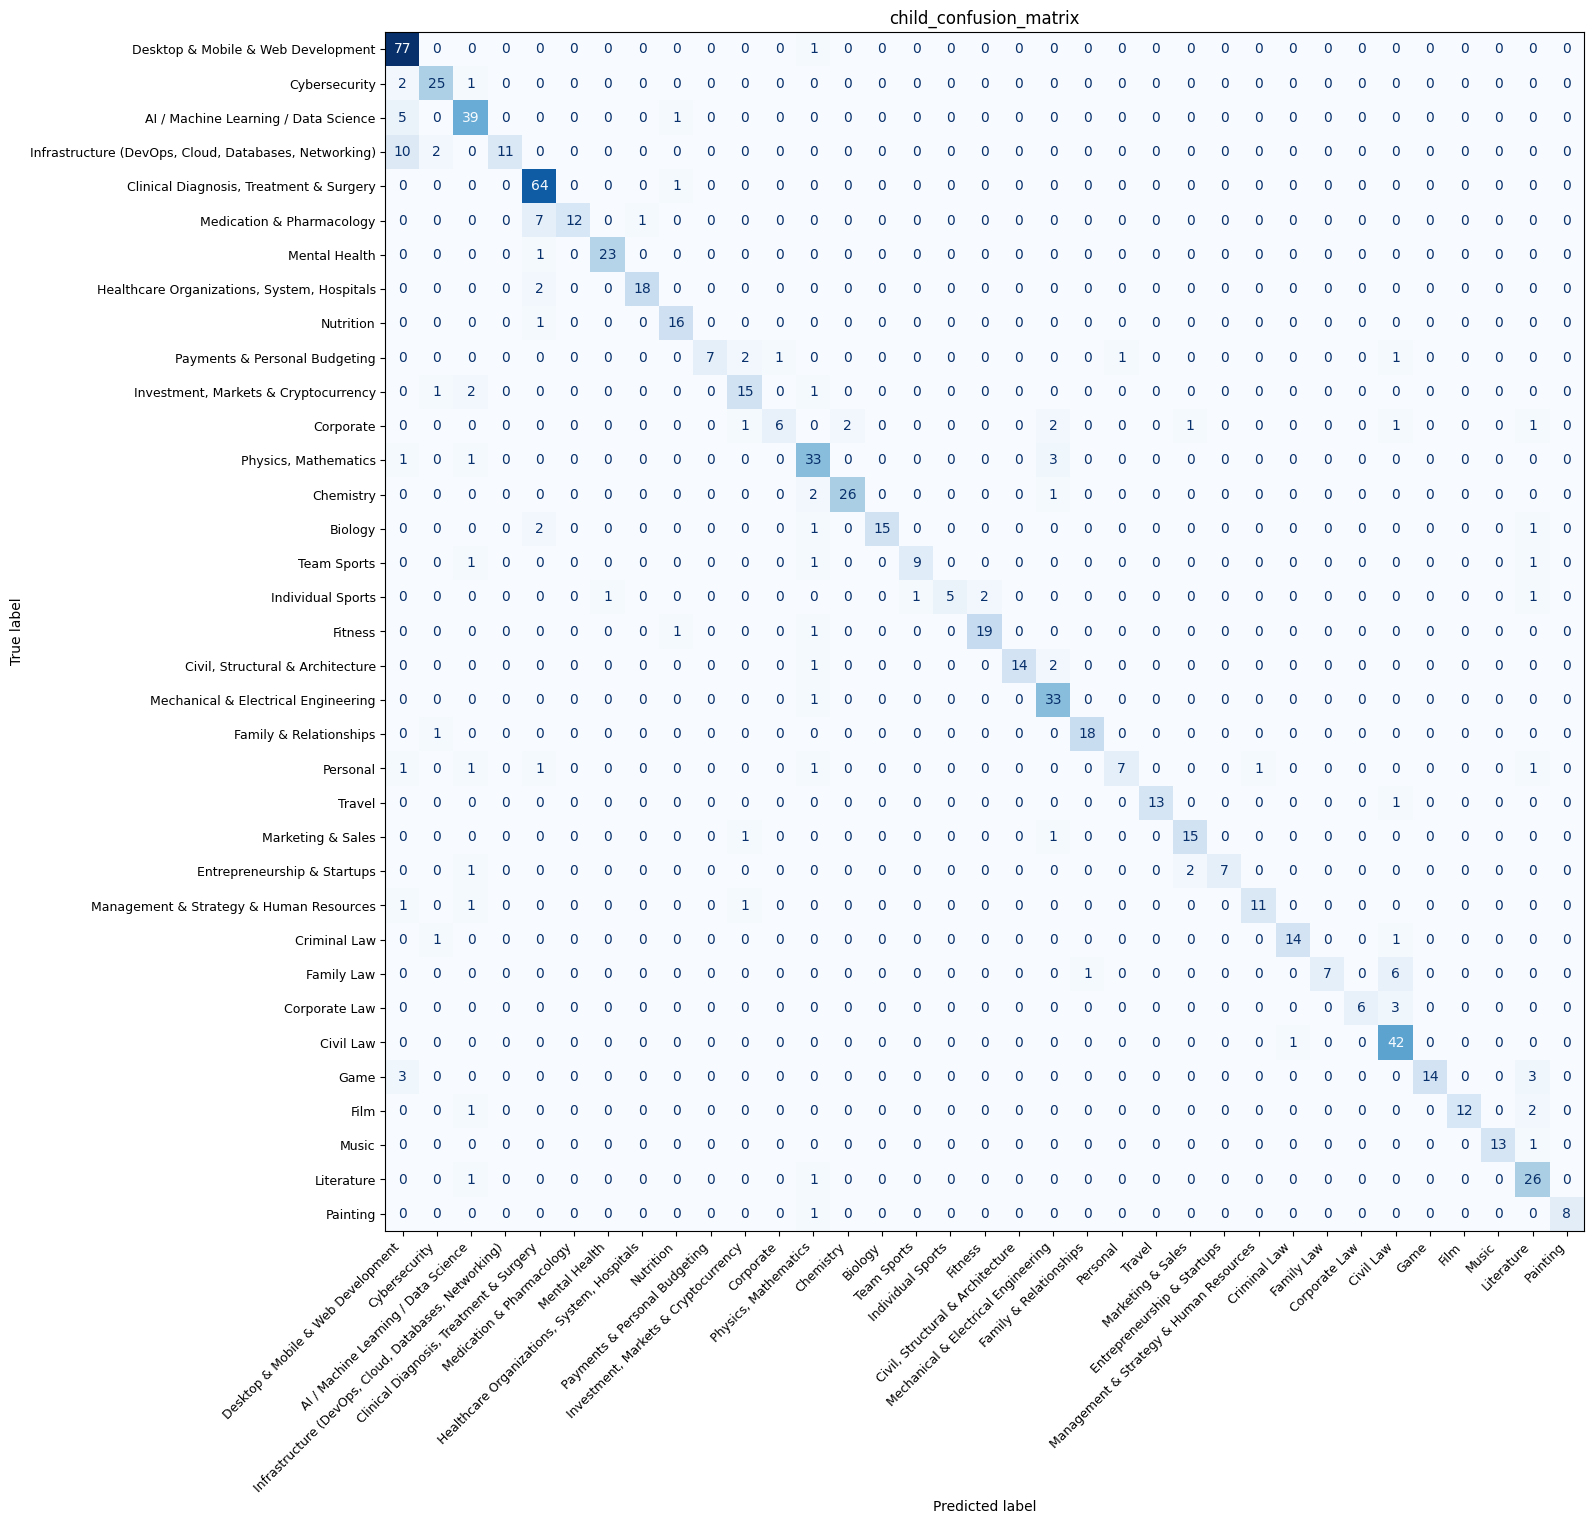

Saved to confusion_matrix.png


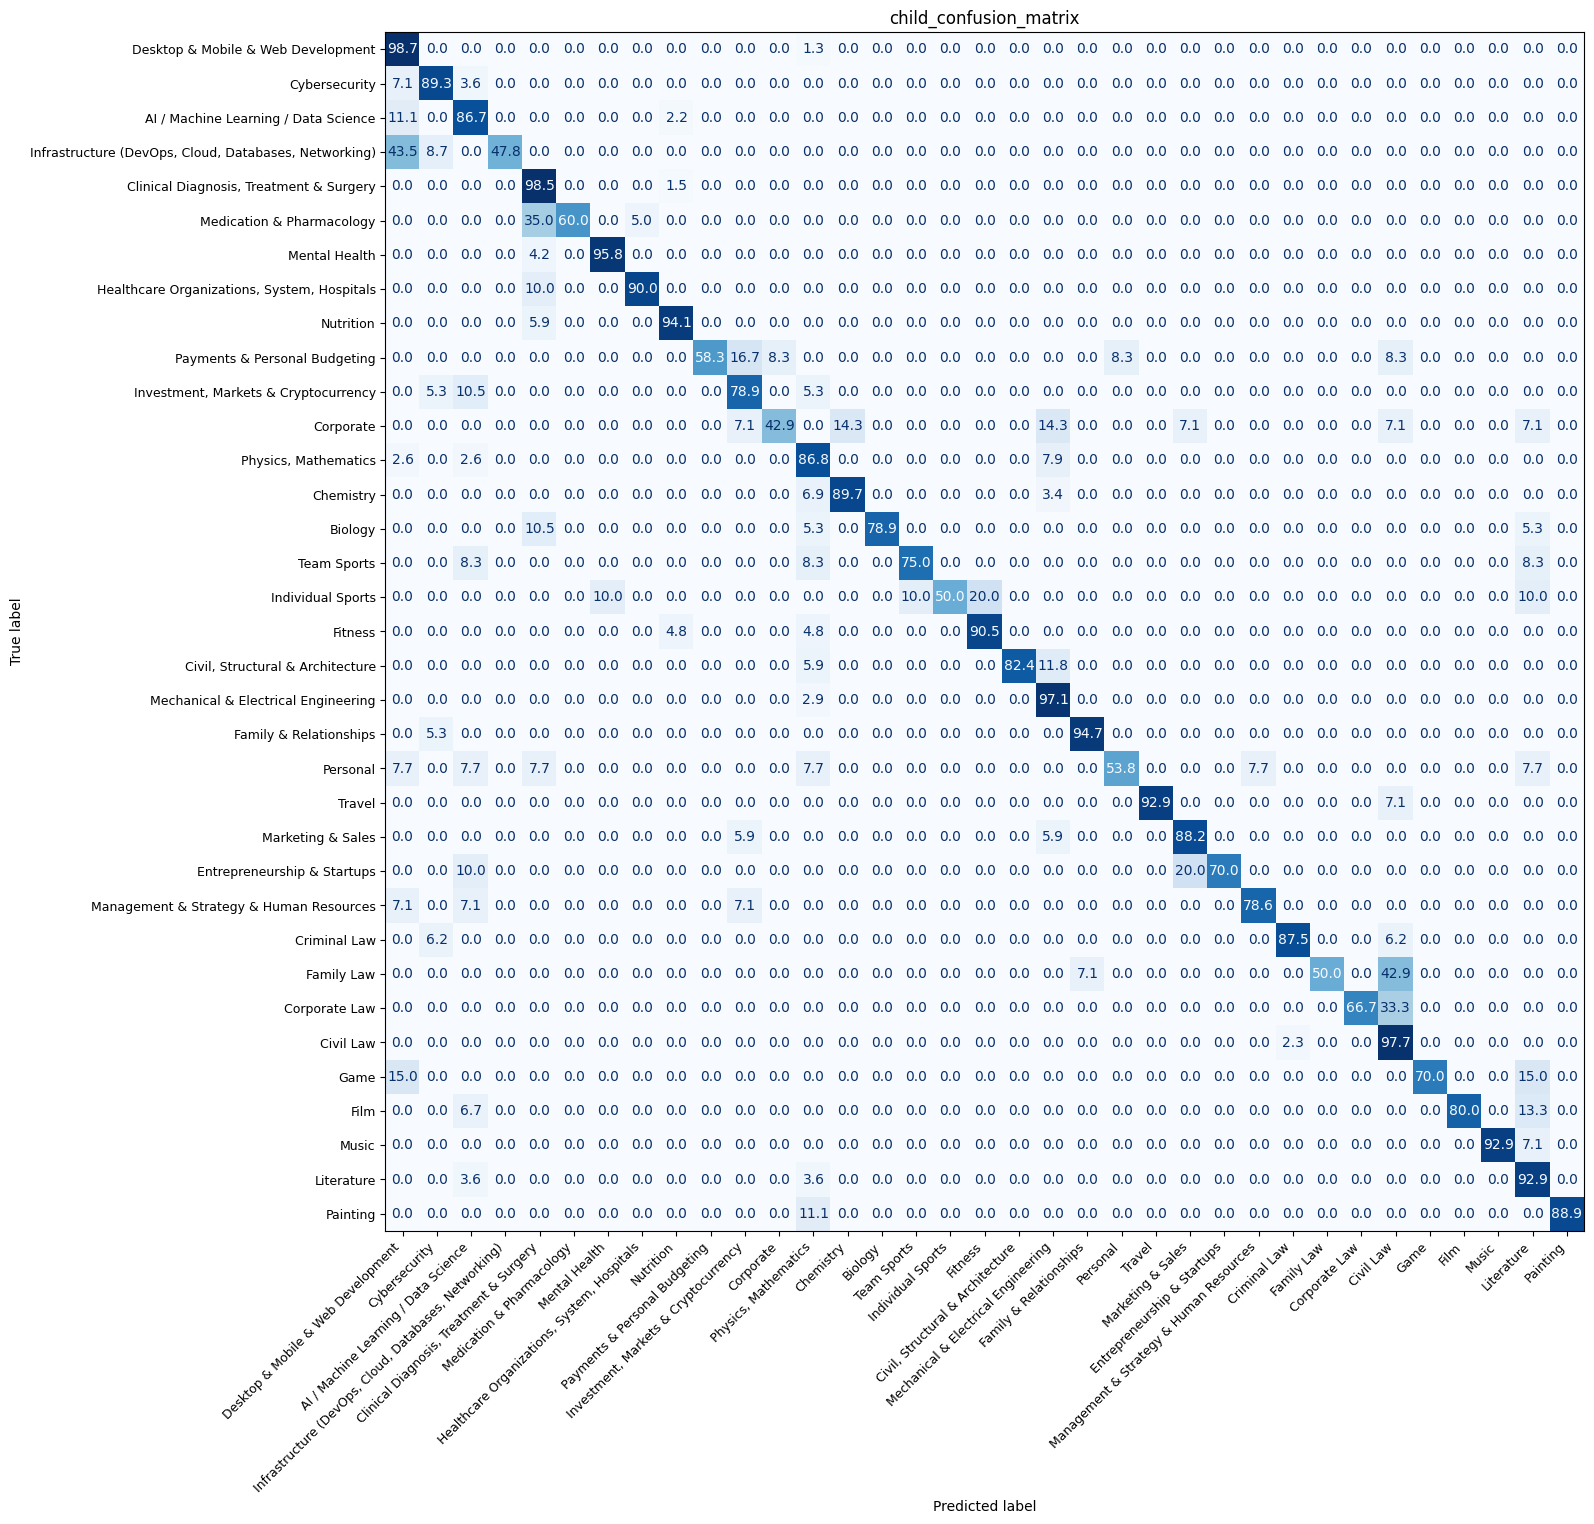

Saved to misclassification_confusion_matrix.png


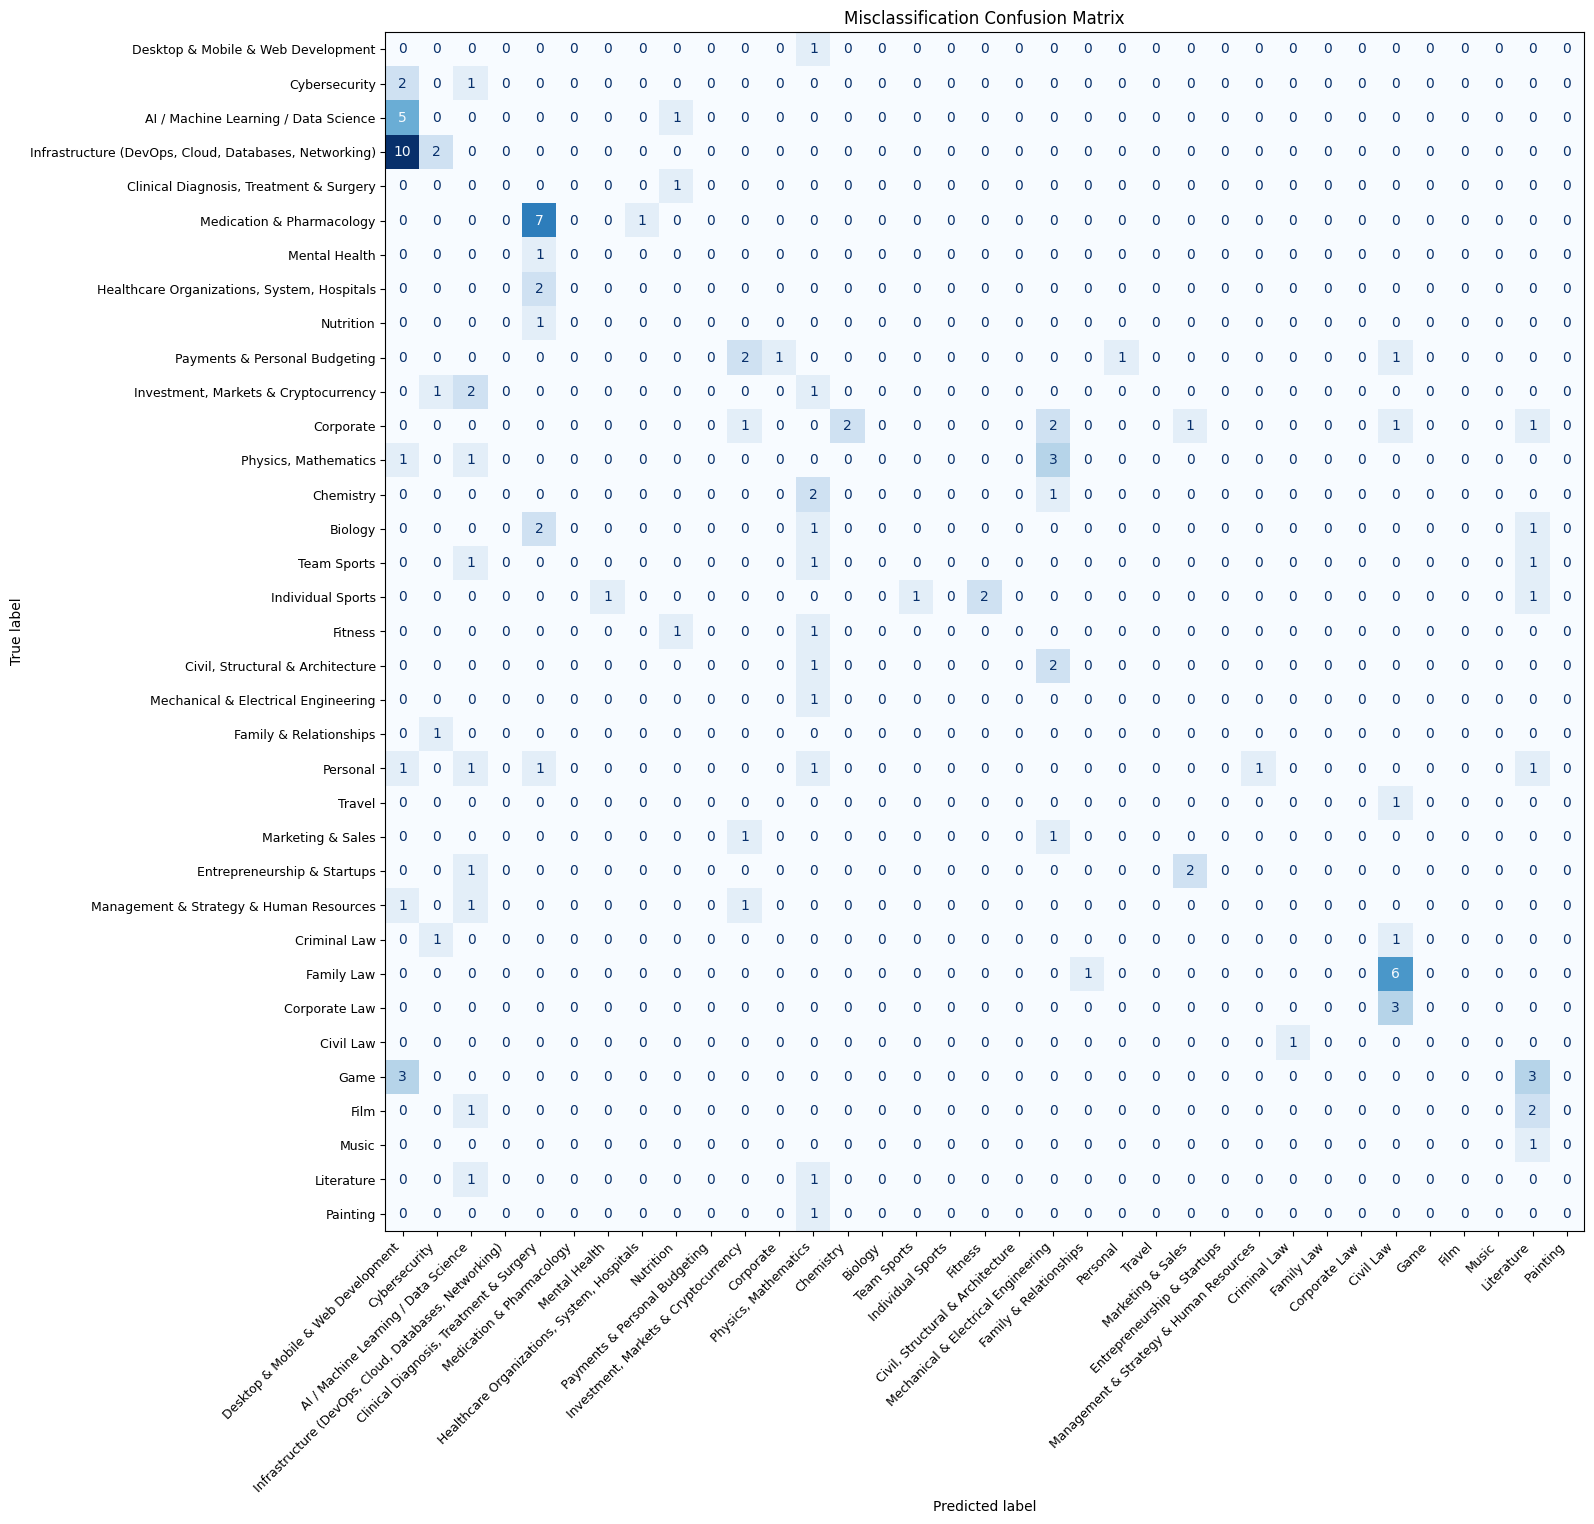

,Parent,Precision Min,Precision Avg,Precision Max,Recall Min,Recall Avg,Recall Max,F1 Min,F1 Avg,F1 Max,Support
0,Programming / Technology,77.00%,84.98%,100.00%,47.83%,80.62%,98.72%,64.71%,80.10%,86.52%,174.0
1,Medical,82.05%,91.37%,100.00%,60.00%,87.68%,98.46%,75.00%,88.31%,95.83%,146.0
2,Finance,75.00%,86.90%,100.00%,42.86%,60.05%,78.95%,57.14%,69.25%,76.92%,45.0
3,Science,73.33%,88.73%,100.00%,78.95%,85.15%,89.66%,79.52%,86.33%,91.23%,86.0
4,Sports,90.00%,93.49%,100.00%,50.00%,71.83%,90.48%,66.67%,79.65%,90.48%,43.0
5,Engineering,78.57%,89.29%,100.00%,82.35%,89.71%,97.06%,86.84%,88.58%,90.32%,51.0
6,Personal,87.50%,94.08%,100.00%,53.85%,80.48%,94.74%,66.67%,85.90%,96.30%,46.0
7,Business,83.33%,91.67%,100.00%,70.00%,78.94%,88.24%,82.35%,84.23%,85.71%,41.0
8,Law,76.36%,92.42%,100.00%,50.00%,75.46%,97.67%,66.67%,80.68%,90.32%,82.0
9,Art,70.27%,94.05%,100.00%,70.00%,84.92%,92.86%,80.00%,88.33%,96.30%,86.0


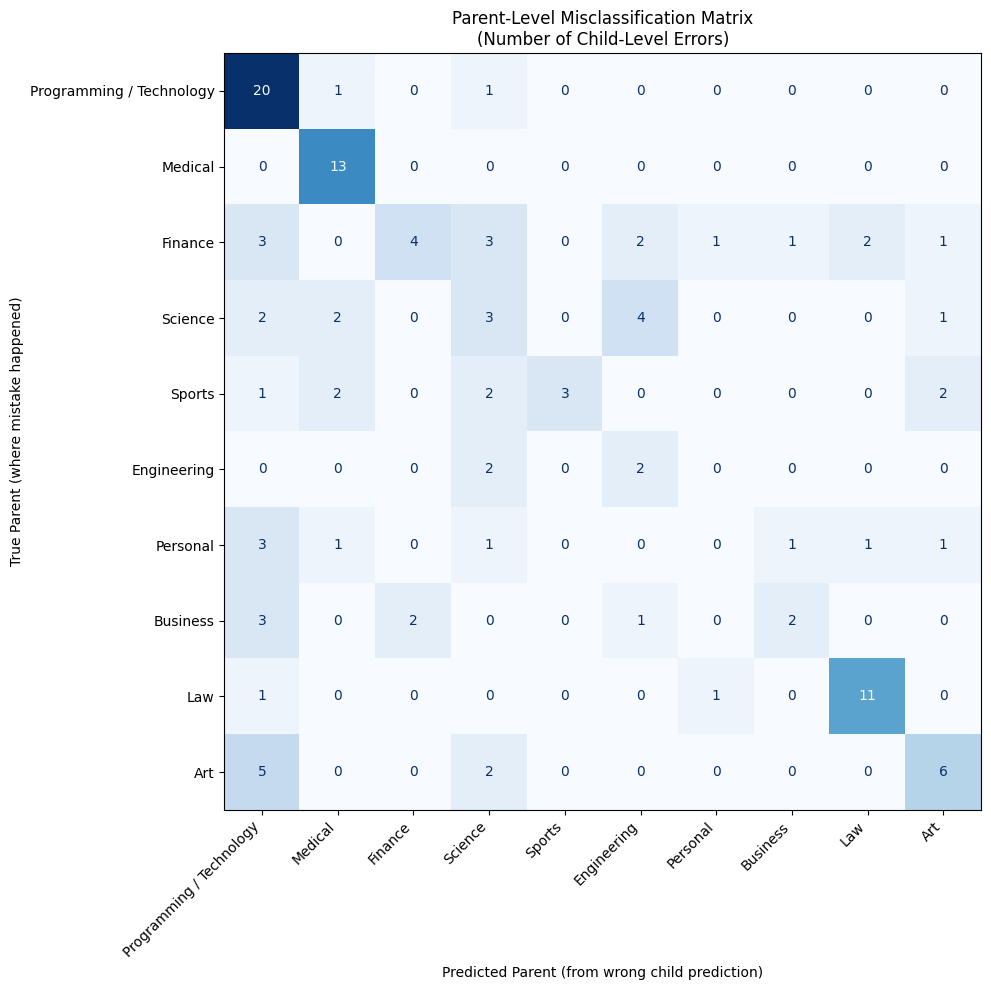

Showing 15 random misclassified samples out of 120

────────────────────────────────────────────────────────────────────────────────────────────────────
Sample 1  |  Test index: 36
────────────────────────────────────────────────────────────────────────────────────────────────────
True label     : Corporate
Predicted label: Literature

Top 10 probabilities:
 1. Literature                               0.1957 ( 19.57%) <-- PREDICTED
 2. AI / Machine Learning / Data Science     0.0942 (  9.42%)
 3. Desktop & Mobile & Web Development       0.0673 (  6.73%)
 4. Game                                     0.0663 (  6.63%)
 5. Family & Relationships                   0.0660 (  6.60%)
 6. Film                                     0.0622 (  6.22%)
 7. Cybersecurity                            0.0429 (  4.29%)
 8. Management & Strategy & Human Resources  0.0395 (  3.95%)
 9. Marketing & Sales                        0.0268 (  2.68%)
10. Corporate                                0.0263 (  2.63%) <-- TR

In [ ]:
y_pred, probabilities = evaluate_model(
    X_test,
    y_test,
    LABEL_ORDER,
    id_to_label,
    HIERARCHY,
    classifier=classifier,
)

In [ ]:
import json
import pandas as pd


def save_misclassified_samples(
    df_test,
    y_test,
    y_pred,
    output_path="misclassified_samples.json",
):
    # Make a copy so we don't modify the original
    df_test = df_test.copy()

    # Add predictions
    df_test["predicted_label"] = y_pred
    misclassified = df_test.copy()

    # Save ALL columns
    misclassified.to_json(
        output_path,
        orient="records",
        force_ascii=False,
        indent=2,
    )

    print(f"Misclassified samples: {len(misclassified)}")
    print(f"Saved to: {output_path}")

    return misclassified

In [ ]:
df_test = test_ds.to_pandas()

In [ ]:
print(df_test.head())

                                                text  \
0  Suggest good research questions based on the T...   
1                    What is Fast Fourier Transform?   
2      can you tell me about spirent communications?   
3  What does "?" mark mean when I programmed in r...   
4  My 8-year-old has been having nightmares and w...   

                  old_label old_parent_label  \
0                      None             None   
1                      None             None   
2                      None             None   
3                      None             None   
4  Mental Health (Clinical)          Medical   

                                     generator_model     source  \
0  deepseek-ai/deepseek-v4-pro-0813/Reasoning = F...       real   
1  deepseek-ai/deepseek-v4-pro-0813/Reasoning = F...       real   
2  deepseek-ai/deepseek-v4-pro-0813/Reasoning = F...       real   
3  deepseek-ai/deepseek-v4-pro-0813/Reasoning = F...       real   
4                                      

In [ ]:
save_misclassified_samples(
    df_test,
    y_test,
    y_pred,
    output_path="misclassified_samples.json",
)

Misclassified samples: 800
Saved to: misclassified_samples.json


,text,old_label,old_parent_label,generator_model,source,generation_group,label,parent_label,use_for_train,label_id,confidence_score,source_dataset,predicted_label
0,Suggest good research questions based on the T...,None,None,deepseek-ai/deepseek-v4-pro-0813/Reasoning = F...,real,None,AI / Machine Learning / Data Science,Programming / Technology,None,2,0.90,lmsys/lmsys-chat-1m,2
1,What is Fast Fourier Transform?,None,None,deepseek-ai/deepseek-v4-pro-0813/Reasoning = F...,real,None,"Physics, Mathematics",Science,None,12,0.90,lmsys/lmsys-chat-1m,12
2,can you tell me about spirent communications?,None,None,deepseek-ai/deepseek-v4-pro-0813/Reasoning = F...,real,None,Corporate,Finance,None,11,0.70,lmsys/lmsys-chat-1m,19
3,"What does ""?"" mark mean when I programmed in r...",None,None,deepseek-ai/deepseek-v4-pro-0813/Reasoning = F...,real,None,Desktop & Mobile & Web Development,Programming / Technology,None,0,0.90,lmsys/lmsys-chat-1m,0
4,My 8-year-old has been having nightmares and w...,Mental Health (Clinical),Medical,deepseek-v4,generated,Medical_parent,Mental Health,Medical,True,6,NaN,None,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,I'm trying to help my mother appeal a denial f...,None,None,deepseek-ai/deepseek-v4-pro-0813/ Reason = False,generated,second_label_desc_single_deepseek_4,"Healthcare Organizations, System, Hospitals",Medical,True,7,NaN,None,7
796,breathing difficulty that worsens at night,"Clinical Diagnosis, Treatment & Surgery",Medical,deepseek-v4,generated,Medical_parent_2,"Clinical Diagnosis, Treatment & Surgery",Medical,True,4,NaN,None,4
797,best cheap audio interface,Music,Art,deepseek-v4,generated,4_labels_1,Music,Art,True,32,NaN,None,32
798,What is the minimum number of training session...,None,None,nvidia/nemotron-3-ultra-550b-a55b/Reasoning = ...,real,None,Fitness,Sports,None,17,0.90,lmsys/lmsys-chat-1m,17


## evaluate with probs

## Entropy

In [ ]:
import numpy as np


def filter_by_entropy(
    y_test,
    probabilities,
    class_ids,
    entropy_threshold=None,
    keep_fraction=None,
):
    """
    Filter test samples using prediction entropy.

    Does NOT need X_test or the classifier.

    Parameters
    ----------
    y_test : array-like
        True labels.

    probabilities : np.ndarray
        Shape: (n_samples, n_classes)
        Output of classifier.predict_proba(X_test).

    class_ids : np.ndarray
        classifier.classes_

    entropy_threshold : float, optional
        Keep samples with entropy <= threshold.

    keep_fraction : float, optional
        Keep the fraction of samples with lowest entropy.
        Example: 0.70 keeps the 70% most confident samples.

    Returns
    -------
    y_test_filtered
        True labels of kept samples.

    probabilities_filtered
        Probability vectors of kept samples.

    info
        Additional information such as predictions, mask,
        entropy, coverage, etc.
    """

    if entropy_threshold is None and keep_fraction is None:
        raise ValueError(
            "Provide either entropy_threshold or keep_fraction."
        )

    if entropy_threshold is not None and keep_fraction is not None:
        raise ValueError(
            "Provide only one of entropy_threshold or keep_fraction."
        )

    probabilities = np.asarray(probabilities)
    y_test = np.asarray(y_test)
    class_ids = np.asarray(class_ids)

    # ------------------------------------------------------------
    # Prediction from probabilities
    # ------------------------------------------------------------

    pred_indices = np.argmax(probabilities, axis=1)

    y_pred = class_ids[pred_indices]

    # ------------------------------------------------------------
    # Entropy
    # ------------------------------------------------------------

    eps = 1e-12

    probabilities_safe = np.clip(
        probabilities,
        eps,
        1.0
    )

    entropy = -np.sum(
        probabilities_safe * np.log(probabilities_safe),
        axis=1
    )

    # ------------------------------------------------------------
    # Determine threshold
    # ------------------------------------------------------------

    if keep_fraction is not None:

        if not 0 < keep_fraction <= 1:
            raise ValueError(
                "keep_fraction must be between 0 and 1."
            )

        threshold = np.quantile(
            entropy,
            keep_fraction
        )

    else:
        threshold = entropy_threshold

    # ------------------------------------------------------------
    # Filter
    # ------------------------------------------------------------

    mask = entropy <= threshold

    y_test_filtered = y_test[mask]

    probabilities_filtered = probabilities[mask]

    y_pred_filtered = y_pred[mask]

    # ------------------------------------------------------------
    # Information
    # ------------------------------------------------------------

    info = {
        "entropy": entropy,
        "predictions": y_pred,
        "mask": mask,
        "threshold": threshold,
        "coverage": mask.mean(),
        "num_kept": int(mask.sum()),
        "num_total": len(mask),
    }

    return (
        y_test_filtered,
        probabilities_filtered,
        info,
    )

## RISK

In [ ]:
import numpy as np


# ============================================================
# 2. SELECTIVE CLASSIFICATION / RISK-COVERAGE
# ============================================================

def filter_by_risk_coverage(
    y_test,
    probabilities,
    class_ids,
    target_accuracy=0.95,
):
    """
    Select confident predictions using selective classification.

    Samples are ranked by maximum predicted probability.
    Keeps the largest prefix whose cumulative accuracy
    is >= target_accuracy.

    No classifier or X_test is required.

    Returns
    -------
    y_test_filtered
        True labels of retained samples.

    probabilities_filtered
        Probability vectors of retained samples.

    info
        Additional filtering information.
    """

    if not 0 < target_accuracy <= 1:
        raise ValueError(
            "target_accuracy must be between 0 and 1."
        )

    y_test = np.asarray(y_test)
    probabilities = np.asarray(probabilities)
    class_ids = np.asarray(class_ids)

    # ============================================================
    # PREDICTIONS FROM PROBABILITIES
    # ============================================================

    prediction_indices = np.argmax(
        probabilities,
        axis=1
    )

    predictions = class_ids[prediction_indices]

    # ============================================================
    # CONFIDENCE
    # ============================================================

    confidence = np.max(
        probabilities,
        axis=1
    )

    correct = predictions == y_test

    # ============================================================
    # SORT MOST CONFIDENT -> LEAST CONFIDENT
    # ============================================================

    order = np.argsort(
        -confidence
    )

    sorted_confidence = confidence[order]
    sorted_correct = correct[order]

    # ============================================================
    # CUMULATIVE ACCURACY
    # ============================================================

    cumulative_correct = np.cumsum(
        sorted_correct
    )

    n = np.arange(
        1,
        len(y_test) + 1
    )

    cumulative_accuracy = (
        cumulative_correct / n
    )

    # ============================================================
    # FIND LARGEST PREFIX WITH TARGET ACCURACY
    # ============================================================

    valid = (
        cumulative_accuracy >= target_accuracy
    )

    if not np.any(valid):
        raise ValueError(
            "No confidence threshold achieves the requested "
            "target accuracy."
        )

    last_valid_index = np.where(valid)[0][-1]

    num_kept = last_valid_index + 1

    threshold = sorted_confidence[
        last_valid_index
    ]

    # ============================================================
    # CREATE MASK IN ORIGINAL ORDER
    # ============================================================

    mask = confidence >= threshold

    # ============================================================
    # FILTER
    # ============================================================

    y_test_filtered = y_test[mask]

    probabilities_filtered = probabilities[mask]

    predictions_filtered = predictions[mask]

    # ============================================================
    # ACTUAL FILTERED METRICS
    # ============================================================

    filtered_accuracy = np.mean(
        predictions_filtered == y_test_filtered
    )

    coverage = mask.mean()

    risk = 1 - filtered_accuracy

    # ============================================================
    # INFO
    # ============================================================

    info = {
        "predictions": predictions,

        "confidence": confidence,

        "correct": correct,

        "mask": mask,

        "confidence_threshold": threshold,

        "accuracy": filtered_accuracy,

        "risk": risk,

        "coverage": coverage,

        "num_kept": int(mask.sum()),

        "num_total": len(mask),

        "target_accuracy": target_accuracy,

        # Full risk-coverage curve
        "risk_curve": 1 - cumulative_accuracy,

        "coverage_curve": n / len(y_test),
    }

    return (
        y_test_filtered,
        probabilities_filtered,
        info,
    )

## gap

In [ ]:
# import numpy as np


# def filter_by_probability_gap(
#     y_test,
#     probabilities,
#     class_ids,
#     min_gap_ratio=3.0,
#     min_group_size=1,
#     max_group_size=None,
# ):
#     """
#     Filter samples based ONLY on the structure of their
#     probability distribution.

#     The idea is to detect a natural gap separating the
#     classifier's main opinion from low-probability noise.

#     No correctness information is used.

#     Examples
#     --------

#     Clear separation:

#         0.15  0.14  0.12  0.11 | 0.05  0.04  0.02
#                                 ^
#                               large gap

#     No clear separation:

#         0.15  0.14  0.13  0.12  0.11  0.10

#     Parameters
#     ----------
#     y_test : array-like
#         Labels. Only returned for the filtered samples.
#         NOT used to determine confidence.

#     probabilities : array-like
#         Probability matrix of shape:

#             (n_samples, n_classes)

#     class_ids : array-like
#         Class ID for each probability column.

#     min_gap_ratio : float
#         How much larger the largest gap must be compared
#         with the typical gap.

#         Example:

#             3.0 -> largest gap must be about 3x
#                    larger than normal gaps.

#     min_group_size : int
#         Minimum number of classes allowed in the
#         high-probability group.

#     max_group_size : int or None
#         Optional maximum number of classes in the
#         high-probability group.

#     Returns
#     -------
#     y_test_filtered
#     probabilities_filtered
#     info
#     """

#     y_test = np.asarray(y_test)
#     probabilities = np.asarray(probabilities)
#     class_ids = np.asarray(class_ids)

#     if probabilities.ndim != 2:
#         raise ValueError(
#             "probabilities must be a 2D array."
#         )

#     if probabilities.shape[1] != len(class_ids):
#         raise ValueError(
#             "Number of probability columns must match "
#             "class_ids."
#         )

#     n_samples, n_classes = probabilities.shape

#     if n_classes < 2:
#         raise ValueError(
#             "At least 2 classes are required."
#         )

#     # --------------------------------------------------------
#     # Sort probabilities for each sample
#     # --------------------------------------------------------

#     sorted_probs = np.sort(
#         probabilities,
#         axis=1
#     )[:, ::-1]

#     # --------------------------------------------------------
#     # Gaps between consecutive probabilities
#     #
#     # Example:
#     #
#     # [0.15, 0.14, 0.12, 0.05]
#     #
#     # gaps:
#     #
#     # [0.01, 0.02, 0.07]
#     # --------------------------------------------------------

#     gaps = (
#         sorted_probs[:, :-1]
#         - sorted_probs[:, 1:]
#     )

#     # --------------------------------------------------------
#     # Find largest gap
#     # --------------------------------------------------------

#     largest_gap_index = np.argmax(
#         gaps,
#         axis=1
#     )

#     largest_gap = np.max(
#         gaps,
#         axis=1
#     )

#     # --------------------------------------------------------
#     # Typical gap
#     #
#     # Use median rather than mean because one huge gap
#     # should not inflate the baseline.
#     # --------------------------------------------------------

#     typical_gap = np.median(
#         gaps,
#         axis=1
#     )

#     # Avoid division by zero
#     eps = 1e-12

#     gap_ratio = (
#         largest_gap /
#         np.maximum(typical_gap, eps)
#     )

#     # --------------------------------------------------------
#     # Size of the group above the largest gap
#     #
#     # If largest gap is between positions 4 and 5,
#     # group size = 4
#     # --------------------------------------------------------

#     group_size = (
#         largest_gap_index + 1
#     )

#     # --------------------------------------------------------
#     # Filter
#     # --------------------------------------------------------

#     mask = (
#         (gap_ratio >= min_gap_ratio)
#         &
#         (group_size >= min_group_size)
#     )

#     if max_group_size is not None:
#         mask &= (
#             group_size <= max_group_size
#         )

#     # --------------------------------------------------------
#     # Filtered data
#     # --------------------------------------------------------

#     y_test_filtered = y_test[mask]

#     probabilities_filtered = probabilities[
#         mask
#     ]

#     # --------------------------------------------------------
#     # Information
#     # --------------------------------------------------------

#     info = {
#         "mask": mask,

#         "sorted_probabilities": sorted_probs,

#         "gaps": gaps,

#         "largest_gap": largest_gap,

#         "largest_gap_index": largest_gap_index,

#         "typical_gap": typical_gap,

#         "gap_ratio": gap_ratio,

#         "group_size": group_size,

#         "coverage": float(mask.mean()),

#         "num_kept": int(mask.sum()),

#         "num_total": int(n_samples),

#         "min_gap_ratio": min_gap_ratio,

#         "min_group_size": min_group_size,

#         "max_group_size": max_group_size,
#     }

#     return (
#         y_test_filtered,
#         probabilities_filtered,
#         info,
#     )

In [ ]:
# import numpy as np


# def filter_by_probability_gap(
#     y_test,
#     probabilities,
#     class_ids,
#     min_gap=0.05,
#     max_group_size=5,
# ):
#     y_test = np.asarray(y_test)
#     probabilities = np.asarray(probabilities)
#     class_ids = np.asarray(class_ids)

#     # Sort probabilities from highest -> lowest
#     sorted_probs = np.sort(
#         probabilities,
#         axis=1
#     )[:, ::-1]

#     # Difference between consecutive probabilities
#     gaps = (
#         sorted_probs[:, :-1]
#         - sorted_probs[:, 1:]
#     )
#     print(gaps[:2])

#     # Find gaps that are large enough
#     significant = gaps >= min_gap
#     print(significant[:2])
#     # Does each sample have at least one significant gap?
#     has_gap = np.any(
#         significant,
#         axis=1
#     )

#     # Find FIRST significant gap
#     first_gap_index = np.argmax(
#         significant,
#         axis=1
#     )

#     # IMPORTANT:
#     # argmax gives 0 when there is no True.
#     # Mark those as -1.
#     first_gap_index = np.where(
#         has_gap,
#         first_gap_index,
#         -1
#     )

#     # Number of probabilities in the group above the gap
#     group_size = first_gap_index + 1

#     # Get the actual first gap
#     first_gap = np.full(
#         len(y_test),
#         np.nan
#     )

#     valid = has_gap

#     first_gap[valid] = gaps[
#         np.arange(len(y_test))[valid],
#         first_gap_index[valid]
#     ]

#     # --------------------------------------------------------
#     # FILTER
#     # --------------------------------------------------------

#     mask = (
#         has_gap
#         &
#         (group_size <= max_group_size)
#     )

#     # --------------------------------------------------------
#     # FILTERED DATA
#     # --------------------------------------------------------

#     y_test_filtered = y_test[mask]

#     probabilities_filtered = probabilities[mask]

#     # --------------------------------------------------------
#     # INFO
#     # --------------------------------------------------------

#     info = {
#         "mask": mask,

#         "sorted_probabilities": sorted_probs,

#         "gaps": gaps,

#         "significant": significant,

#         "has_gap": has_gap,

#         "first_gap_index": first_gap_index,

#         "first_gap": first_gap,

#         "group_size": group_size,

#         "coverage": mask.mean(),

#         "num_kept": int(mask.sum()),

#         "num_total": len(mask),

#         "min_gap": min_gap,

#         "max_group_size": max_group_size,
#     }

#     return (
#         y_test_filtered,
#         probabilities_filtered,
#         info,
#     )

gap2

In [ ]:
import numpy as np


def filter_by_probability_gap(
    y_test,
    probabilities,
    class_ids,
    min_gap=0.15,
):
    """
    Keep samples where there is a significant probability
    gap among the top 5 probabilities.

    Only probabilities are used to determine filtering.
    Prediction correctness is NOT checked.

    We sort probabilities from highest to lowest and check:

        top[0] - top[1]
        top[1] - top[2]
        top[2] - top[3]
        top[3] - top[4]

    If any gap >= min_gap, the sample is kept.
    """

    y_test = np.asarray(y_test)
    probabilities = np.asarray(probabilities)
    class_ids = np.asarray(class_ids)

    # --------------------------------------------------------
    # Sort probabilities: highest -> lowest
    # --------------------------------------------------------

    sorted_probs = np.sort(
        probabilities,
        axis=1
    )[:, ::-1]

    # --------------------------------------------------------
    # Take top 5
    # --------------------------------------------------------

    top_k = min(4, probabilities.shape[1])

    top_probs = sorted_probs[:, :top_k]
    # print(top_probs[0])
    # --------------------------------------------------------
    # Calculate gaps between consecutive top probabilities
    #
    # [0.30, 0.29, 0.10, 0.05, 0.02]
    #
    # becomes
    #
    # [0.01, 0.19, 0.05, 0.03]
    # --------------------------------------------------------

    gaps = (
        top_probs[:, :-1]
        - top_probs[:, 1:]
    )
    # print(gaps[0])

    # --------------------------------------------------------
    # Keep if ANY gap >= min_gap
    # --------------------------------------------------------

    mask = np.any(
        gaps >= min_gap,
        axis=1
    )
    # print(mask[0])

    # --------------------------------------------------------
    # Filter
    # --------------------------------------------------------

    y_test_filtered = y_test[mask]

    probabilities_filtered = probabilities[mask]
    # print(y_test_filtered[0])
    # print(probabilities_filtered[0])

    # --------------------------------------------------------
    # Information
    # --------------------------------------------------------

    info = {
        "mask": mask,

        "sorted_probabilities": sorted_probs,

        "top_probabilities": top_probs,

        "gaps": gaps,

        "coverage": mask.mean(),

        "num_kept": int(mask.sum()),

        "num_total": len(mask),

        "min_gap": min_gap,
    }

    return (
        y_test_filtered,
        probabilities_filtered,
        info,
    )

In [ ]:
label_order = LABEL_ORDER

# evaluate

In [ ]:
def evaluate_filtered_model(
    label_order,
    id_to_label,
    hierarchy,
    filter_function,
    filter_kwargs=None,
    predictions_path="test_predictions.npz",
    n_misclassified=15,
    random_state=42,
):
    """
    Evaluate a filtered test set using previously saved
    y_test, y_pred, probabilities, and class_ids.

    No X_test and no classifier prediction are required.

    Parameters
    ----------
    label_order : list
        Labels in the desired display order.

    id_to_label : dict
        Mapping from label ID to label name.

    hierarchy : dict
        Parent/child hierarchy.

    filter_function : function
        Filtering function, e.g. filter_by_entropy.

    filter_kwargs : dict
        Arguments for the filtering function.

    predictions_path : str
        Path to saved .npz prediction file.

    n_misclassified : int
        Number of random misclassified samples to display.

    random_state : int
        Random seed.
    """

    if filter_kwargs is None:
        filter_kwargs = {}

    # ============================================================
    # LOAD ORIGINAL RESULTS
    # ============================================================

    y_test, y_pred, probabilities, class_ids = load_test_results(
        predictions_path
    )

    # ============================================================
    # APPLY FILTER
    # ============================================================

    (
        y_test_filtered,
        probabilities_filtered,
        filter_info,
    ) = filter_function(
        y_test=y_test,
        probabilities=probabilities,
        class_ids=class_ids,
        **filter_kwargs,
    )

    # ============================================================
    # GET FILTERED PREDICTIONS
    # ============================================================

    y_pred_filtered = class_ids[
        np.argmax(
            probabilities_filtered,
            axis=1
        )
    ]

    # ============================================================
    # FILTERED MODEL EVALUATION
    # ============================================================

    print("\n")
    print("=" * 100)
    print("--- Filtered Model Evaluation ---")
    print("=" * 100)

    print(
        f"Coverage: "
        f"{len(y_test_filtered) / len(y_test):.2%}"
    )

    print(
        f"Samples kept: "
        f"{len(y_test_filtered)} / {len(y_test)}"
    )

    print(
        f"Accuracy: "
        f"{accuracy_score(y_test_filtered, y_pred_filtered):.2%}"
    )

    print("\nClassification Report:\n")

    report = show_classification_report(
        y_test_filtered,
        y_pred_filtered,
        label_order,
    )

    # ============================================================
    # CONFUSION MATRICES
    # ============================================================

    plot_child_confusion_matrix_old(
        y_test_filtered,
        y_pred_filtered,
        label_order,
    )

    plot_child_confusion_matrix(
        y_test_filtered,
        y_pred_filtered,
        label_order,
    )

    plot_misclassification_confusion_matrix(
        y_test_filtered,
        y_pred_filtered,
        label_order,
    )

    # ============================================================
    # PARENT SUMMARY
    # ============================================================

    show_parent_summary(
        report,
        hierarchy,
    )

    plot_parent_misclassification_matrix(
        y_test_filtered,
        y_pred_filtered,
        hierarchy,
        id_to_label,
    )

    # ============================================================
    # SHOW RANDOM MISCLASSIFICATIONS
    # ============================================================

    show_random_misclassified_probabilities(
        y_test=y_test_filtered,
        y_pred=y_pred_filtered,
        probabilities=probabilities_filtered,
        class_ids=class_ids,
        id_to_label=id_to_label,
        n_samples=n_misclassified,
        random_state=random_state,
    )

    # ============================================================
    # RETURN ONLY WHAT YOU WANT
    # ============================================================

    return y_test_filtered, probabilities_filtered

In [ ]:
# y_test_filtered, probs_filtered = evaluate_filtered_model(
#     label_order=label_order,
#     id_to_label=id_to_label,
#     hierarchy=HIERARCHY,

#     filter_function=filter_by_entropy,

#     filter_kwargs={
#         "keep_fraction": 0.70,
#     },

#     predictions_path="test_predictions.npz",

#     n_misclassified=15,
#     random_state=42,
# )

In [ ]:
# y_test_filtered, probs_filtered = evaluate_filtered_model(
#     label_order=label_order,
#     id_to_label=id_to_label,
#     hierarchy=HIERARCHY,

#     filter_function=filter_by_risk_coverage,

#     filter_kwargs={
#         "target_accuracy": 0.8,
#     },

#     predictions_path="test_predictions.npz",

#     n_misclassified=15,
#     random_state=42,
# )



--- Filtered Model Evaluation ---
Coverage: 80.88%
Samples kept: 647 / 800
Accuracy: 90.57%

Classification Report:


--- Model Evaluation ---
Accuracy: 90.57%

                                                       precision    recall  f1-score   support

                   Desktop & Mobile & Web Development       0.82      1.00      0.90        73
                                        Cybersecurity       0.85      0.96      0.90        24
                 AI / Machine Learning / Data Science       0.95      0.88      0.91        42
Infrastructure (DevOps, Cloud, Databases, Networking)       1.00      0.48      0.65        21
              Clinical Diagnosis, Treatment & Surgery       0.88      1.00      0.93        63
                            Medication & Pharmacology       1.00      0.62      0.77        16
                                        Mental Health       1.00      0.95      0.98        22
          Healthcare Organizations, System, Hospitals       1.00      0.95  

,Metric,Test
0,Accuracy,90.57%
1,Macro F1-Score,89.89%
2,Weighted F1-Score,90.09%


Saved to confusion_matrix.png


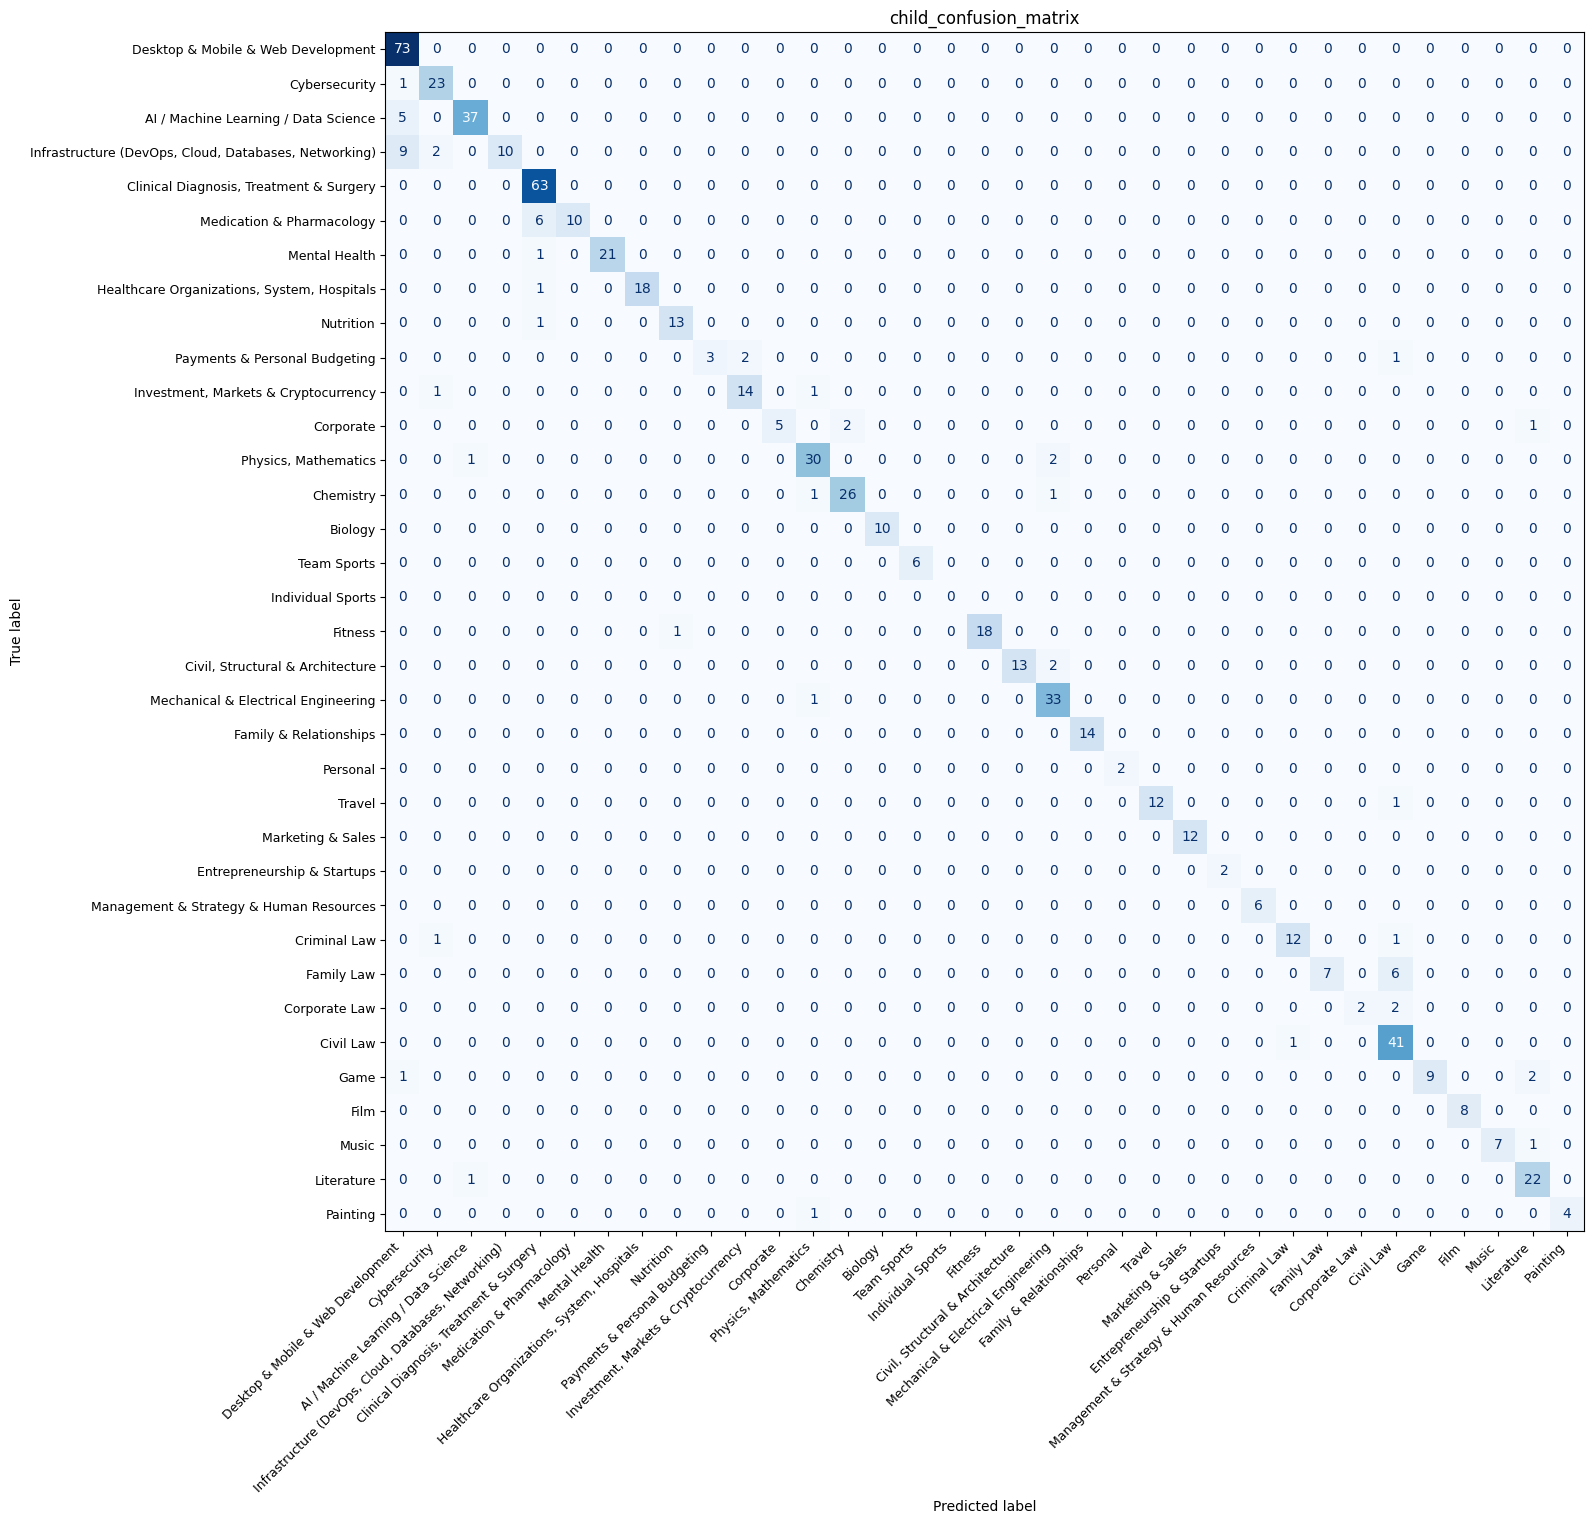

Saved to confusion_matrix.png


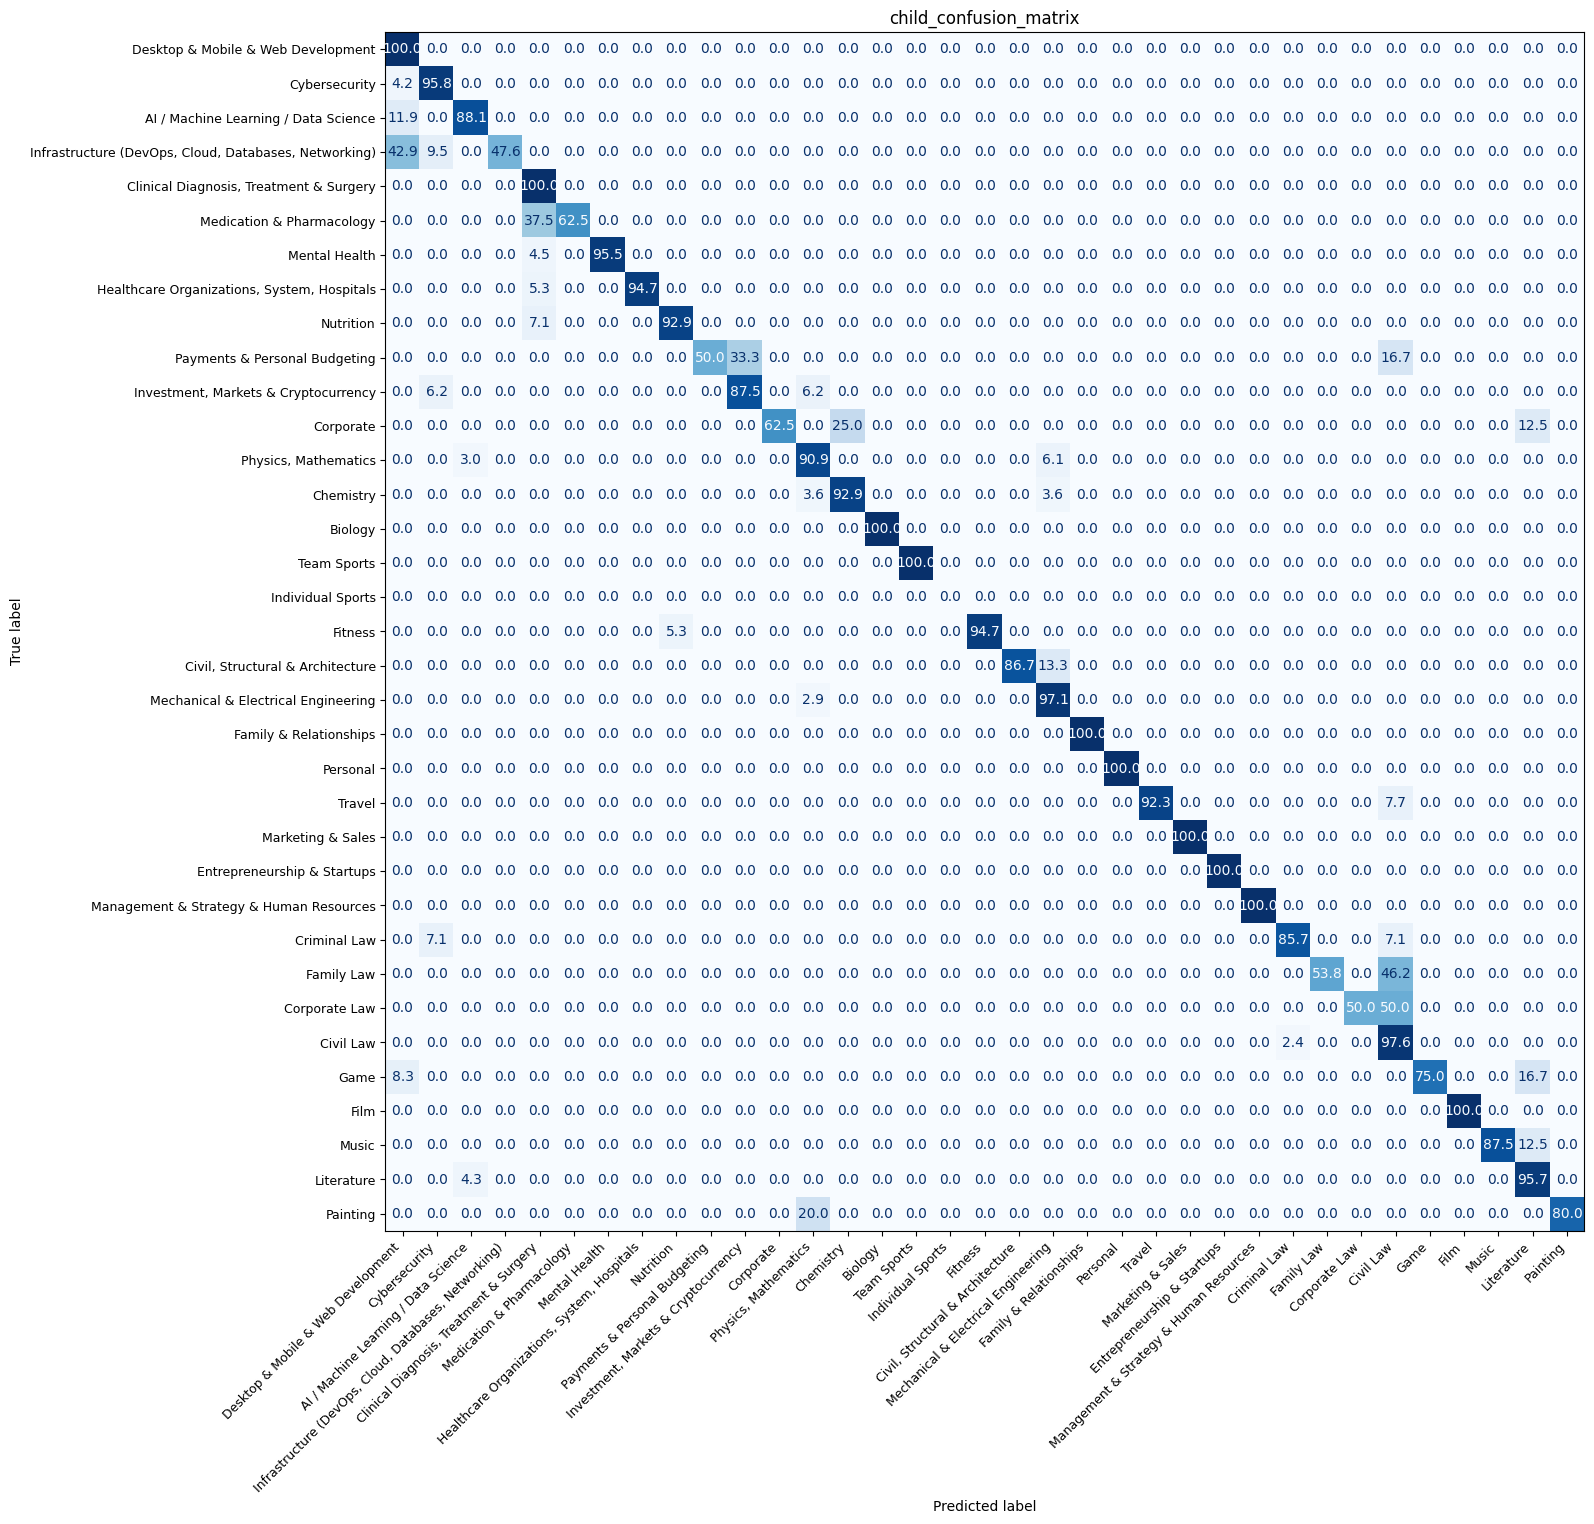

Saved to misclassification_confusion_matrix.png


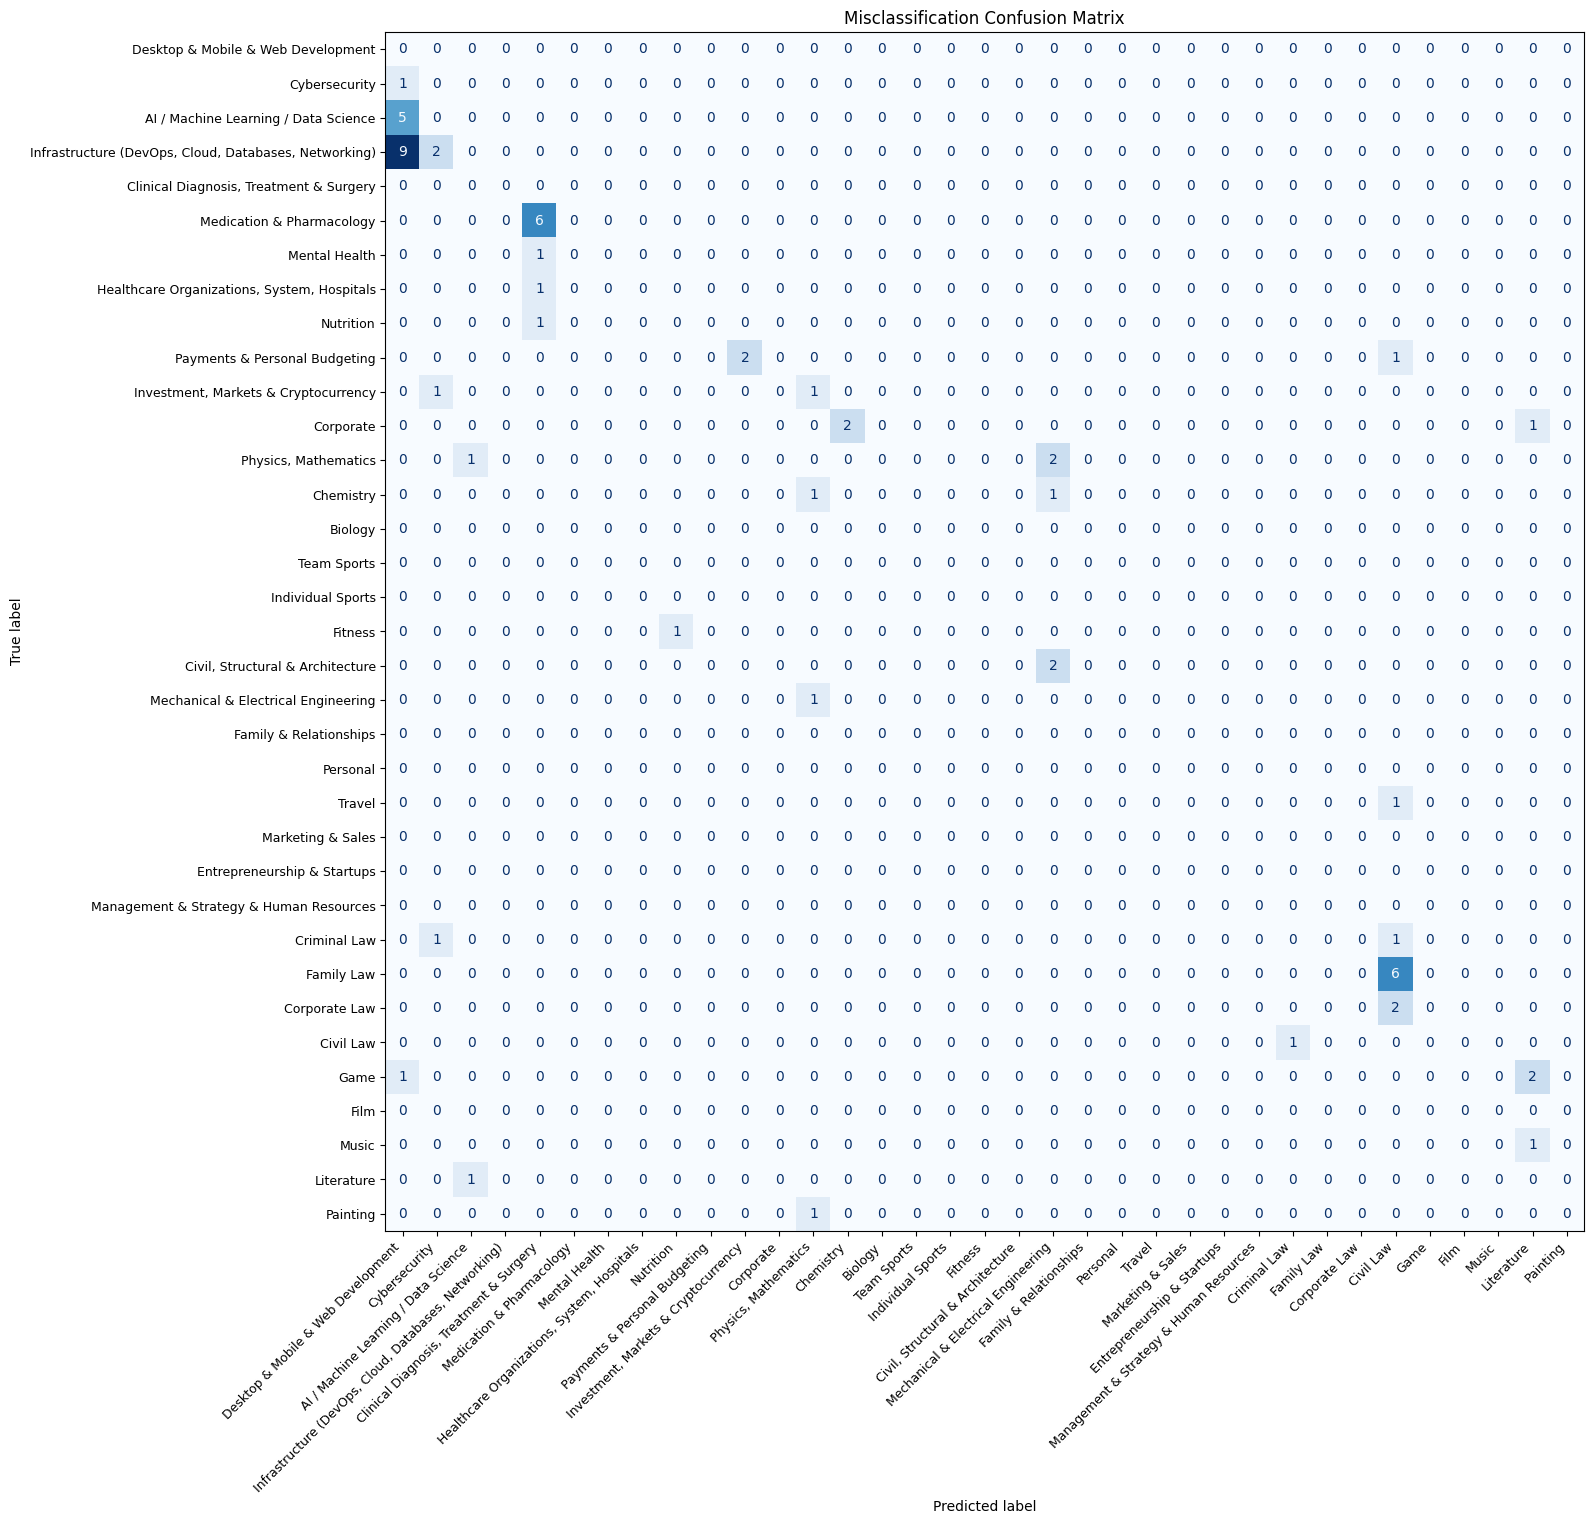

,Parent,Precision Min,Precision Avg,Precision Max,Recall Min,Recall Avg,Recall Max,F1 Min,F1 Avg,F1 Max,Support
0,Programming / Technology,82.02%,90.52%,100.00%,47.62%,82.89%,100.00%,64.52%,84.05%,91.36%,160.0
1,Medical,87.50%,96.07%,100.00%,62.50%,89.11%,100.00%,76.92%,91.62%,97.67%,134.0
2,Finance,87.50%,95.83%,100.00%,50.00%,66.67%,87.50%,66.67%,77.03%,87.50%,30.0
3,Science,88.24%,93.70%,100.00%,90.91%,94.59%,100.00%,89.55%,94.14%,100.00%,71.0
4,Sports,0.00%,66.67%,100.00%,0.00%,64.91%,100.00%,0.00%,65.77%,100.00%,25.0
5,Engineering,86.84%,93.42%,100.00%,86.67%,91.86%,97.06%,91.67%,92.26%,92.86%,49.0
6,Personal,100.00%,100.00%,100.00%,92.31%,97.44%,100.00%,96.00%,98.67%,100.00%,29.0
7,Business,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,100.00%,20.0
8,Law,78.85%,92.79%,100.00%,50.00%,71.79%,97.62%,66.67%,78.20%,88.89%,73.0
9,Art,84.62%,96.92%,100.00%,75.00%,87.63%,100.00%,85.71%,91.55%,100.00%,56.0


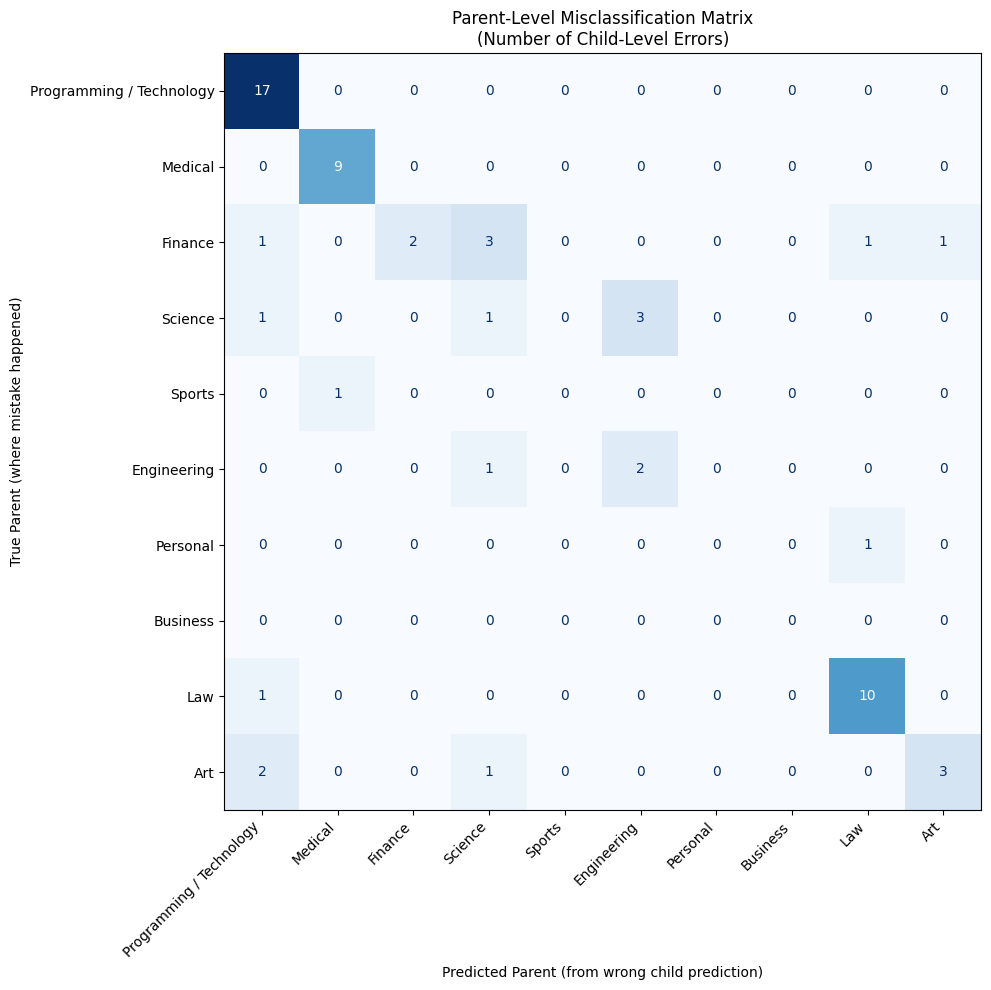

Showing 15 random misclassified samples out of 61

────────────────────────────────────────────────────────────────────────────────────────────────────
Sample 1  |  Test index: 21
────────────────────────────────────────────────────────────────────────────────────────────────────
True label     : Game
Predicted label: Desktop & Mobile & Web Development

Top 10 probabilities:
 1. Desktop & Mobile & Web Development       0.5674 ( 56.74%) <-- PREDICTED
 2. Game                                     0.1611 ( 16.11%) <-- TRUE
 3. AI / Machine Learning / Data Science     0.0362 (  3.62%)
 4. Cybersecurity                            0.0286 (  2.86%)
 5. Literature                               0.0248 (  2.48%)
 6. Infrastructure (DevOps, Cloud, Databases, Networking) 0.0140 (  1.40%)
 7. Clinical Diagnosis, Treatment & Surgery  0.0108 (  1.08%)
 8. Music                                    0.0088 (  0.88%)
 9. Fitness                                  0.0087 (  0.87%)
10. Personal                

In [ ]:
y_test_filtered, probs_filtered = evaluate_filtered_model(
    label_order=label_order,
    id_to_label=id_to_label,
    hierarchy=HIERARCHY,

    filter_function=filter_by_probability_gap,

    filter_kwargs={
        "min_gap": 0.1,
        # "min_group_size": 1,
        # "max_group_size": 5,  # optional
    },

    predictions_path="test_predictions.npz",

    n_misclassified=15,
    random_state=42,
)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score


def evaluate_gap_thresholds(
    predictions_path="test_predictions.npz",
    min_gap_values=None,
):
    """
    Evaluate probability-gap filtering over multiple min_gap values.

    Returns a DataFrame containing:
        min_gap
        coverage
        accuracy
        num_kept
        num_total
    """

    # --------------------------------------------------------
    # Load saved test results
    # --------------------------------------------------------

    data = np.load(predictions_path)

    y_test = data["y_test"]
    probabilities = data["probabilities"]
    class_ids = data["class_ids"]

    # --------------------------------------------------------
    # Default thresholds
    # --------------------------------------------------------

    if min_gap_values is None:
        min_gap_values = [
            0.01,
            0.02,
            0.03,
            0.04,
            0.05,
            0.06,
            0.07,
            0.08,
            0.10,
            0.12,
            0.15,
        ]

    results = []

    # --------------------------------------------------------
    # Test every threshold
    # --------------------------------------------------------

    for min_gap in min_gap_values:

        y_filtered, probs_filtered, info = (
            filter_by_probability_gap(
                y_test=y_test,
                probabilities=probabilities,
                class_ids=class_ids,
                min_gap=min_gap,
            )
        )

        # Reconstruct predictions from probabilities
        if len(probs_filtered) > 0:

            prediction_indices = np.argmax(
                probs_filtered,
                axis=1
            )

            y_pred_filtered = class_ids[
                prediction_indices
            ]

            accuracy = accuracy_score(
                y_filtered,
                y_pred_filtered
            )

        else:
            accuracy = np.nan

        coverage = (
            len(y_filtered) / len(y_test)
        )

        results.append({
            "min_gap": min_gap,
            "coverage": coverage,
            "accuracy": accuracy,
            "num_kept": len(y_filtered),
            "num_total": len(y_test),
        })

    # --------------------------------------------------------
    # Create table
    # --------------------------------------------------------

    results_df = pd.DataFrame(results)

    # Convert to percentages
    results_df["coverage"] = (
        results_df["coverage"] * 100
    )

    results_df["accuracy"] = (
        results_df["accuracy"] * 100
    )

    return results_df

In [ ]:
results_df = evaluate_gap_thresholds(
    predictions_path="test_predictions.npz",

    min_gap_values=[
        0.01,
        0.02,
        0.03,
        0.04,
        0.05,
        0.06,
        0.07,
        0.08,
        0.10,
        0.12,
        0.15,
        0.20,
        0.30,
    ],
)

print(results_df.to_string(index=False))

 min_gap  coverage  accuracy  num_kept  num_total
    0.01   100.000 88.375000       800        800
    0.02    99.500 88.693467       796        800
    0.03    98.750 89.113924       790        800
    0.04    98.000 89.795918       784        800
    0.05    97.875 89.910600       783        800
    0.06    96.625 90.556274       773        800
    0.07    96.000 90.625000       768        800
    0.08    94.750 90.765172       758        800
    0.10    92.500 91.621622       740        800
    0.12    89.875 92.211405       719        800
    0.15    86.750 93.083573       694        800
    0.20    80.125 94.383775       641        800
    0.30    66.375 96.045198       531        800


In [ ]:
from sklearn.metrics import classification_report, accuracy_score, f1_score
import pandas as pd

print("\n--- Filtered Model Evaluation ---")

print(
    f"Coverage: {len(y_test_filtered) / len(y_test):.2%}"
)

print(
    f"Accuracy: "
    f"{accuracy_score(y_test_filtered, y_pred_filtered):.2%}\n"
)

print(
    classification_report(
        y_test_filtered,
        y_pred_filtered,
        labels=list(range(len(label_order))),
        target_names=label_order,
        zero_division=0,
    )
)


--- Filtered Model Evaluation ---
Coverage: 58.10%
Accuracy: 90.54%

                                                       precision    recall  f1-score   support

                   Desktop & Mobile & Web Development       0.92      0.86      0.89       191
                                        Cybersecurity       0.79      0.79      0.79        33
                 AI / Machine Learning / Data Science       0.82      0.93      0.87       139
Infrastructure (DevOps, Cloud, Databases, Networking)       0.96      0.84      0.90        32
              Clinical Diagnosis, Treatment & Surgery       0.92      0.92      0.92        12
                            Medication & Pharmacology       0.55      1.00      0.71         6
                                        Mental Health       0.90      0.90      0.90        10
          Healthcare Organizations, System, Hospitals       1.00      0.80      0.89         5
                                            Nutrition       0.95      0.95

In [ ]:
import json
import numpy as np


def save_filtered_test_json(
    output_path,
    df_test_filtered,
    y_test_filtered,
    y_pred_filtered,
    probabilities_filtered,
    class_ids,
    original_indices,
    id_to_label,
):
    """
    Save filtered test samples and their predictions
    into a JSON file.

    Each JSON entry corresponds to one filtered sample.
    """

    records = []

    for i in range(len(y_test_filtered)):

        true_id = y_test_filtered[i]
        pred_id = y_pred_filtered[i]

        # Convert probability array into:
        # {label_name: probability}
        probability_dict = {}

        for prob_idx, class_id in enumerate(class_ids):

            label_name = id_to_label.get(
                class_id,
                str(class_id)
            )

            probability_dict[label_name] = float(
                probabilities_filtered[i][prob_idx]
            )

        # Original dataframe row
        row = df_test_filtered.iloc[i].to_dict()

        # Convert numpy values to normal Python values
        clean_row = {}

        for key, value in row.items():

            if isinstance(value, np.generic):
                value = value.item()

            clean_row[key] = value

        record = {
            "original_index": int(
                original_indices[i]
            ),

            # Original df_test data
            "data": clean_row,

            # Classification information
            "true_label_id": int(true_id),
            "predicted_label_id": int(pred_id),

            "true_label": id_to_label.get(
                true_id,
                str(true_id)
            ),

            "predicted_label": id_to_label.get(
                pred_id,
                str(pred_id)
            ),

            # Full probability distribution
            "probabilities": probability_dict,

            # Maximum probability
            "confidence": float(
                np.max(probabilities_filtered[i])
            ),

            # Whether prediction was correct
            "correct": bool(
                true_id == pred_id
            ),
        }

        records.append(record)

    # ============================================================
    # SAVE
    # ============================================================

    with open(
        output_path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            records,
            f,
            ensure_ascii=False,
            indent=2
        )

    print(
        f"Saved {len(records)} samples to "
        f"{output_path}"
    )

In [ ]:
def evaluate_filtered_model(
    df_test,
    label_order,
    id_to_label,
    hierarchy,
    filter_function,
    filter_kwargs=None,
    predictions_path="test_predictions.npz",
    n_misclassified=15,
    random_state=42,
):
    """
    Evaluate a filtered test set using previously saved
    y_test, y_pred, probabilities, and class_ids.

    Also returns the corresponding filtered rows from df_test.
    """

    if filter_kwargs is None:
        filter_kwargs = {}

    # ============================================================
    # LOAD ORIGINAL RESULTS
    # ============================================================

    y_test, y_pred, probabilities, class_ids = load_test_results(
        predictions_path
    )

    # Safety check
    if len(df_test) != len(y_test):
        raise ValueError(
            f"df_test has {len(df_test)} rows, "
            f"but y_test has {len(y_test)} samples."
        )

    # ============================================================
    # APPLY FILTER
    # ============================================================

    (
        y_test_filtered,
        probabilities_filtered,
        filter_info,
    ) = filter_function(
        y_test=y_test,
        probabilities=probabilities,
        class_ids=class_ids,
        **filter_kwargs,
    )

    # ============================================================
    # GET FILTER MASK
    # ============================================================

    mask = filter_info["mask"]

    # Original positions of samples that survived filtering
    original_indices = np.where(mask)[0]

    # ============================================================
    # FILTER df_test
    # ============================================================

    df_test_filtered = df_test.iloc[
        original_indices
    ].copy()

    # ============================================================
    # GET FILTERED PREDICTIONS
    # ============================================================

    y_pred_filtered = class_ids[
        np.argmax(
            probabilities_filtered,
            axis=1
        )
    ]

    # ============================================================
    # FILTERED MODEL EVALUATION
    # ============================================================

    print("\n")
    print("=" * 100)
    print("--- Filtered Model Evaluation ---")
    print("=" * 100)

    print(
        f"Coverage: "
        f"{len(y_test_filtered) / len(y_test):.2%}"
    )

    print(
        f"Samples kept: "
        f"{len(y_test_filtered)} / {len(y_test)}"
    )

    print(
        f"Accuracy: "
        f"{accuracy_score(y_test_filtered, y_pred_filtered):.2%}"
    )

    print("\nClassification Report:\n")

    report = show_classification_report(
        y_test_filtered,
        y_pred_filtered,
        label_order,
    )

    # ============================================================
    # CONFUSION MATRICES
    # ============================================================

    plot_child_confusion_matrix_old(
        y_test_filtered,
        y_pred_filtered,
        label_order,
    )

    plot_child_confusion_matrix(
        y_test_filtered,
        y_pred_filtered,
        label_order,
    )

    plot_misclassification_confusion_matrix(
        y_test_filtered,
        y_pred_filtered,
        label_order,
    )

    # ============================================================
    # PARENT SUMMARY
    # ============================================================

    show_parent_summary(
        report,
        hierarchy,
    )

    plot_parent_misclassification_matrix(
        y_test_filtered,
        y_pred_filtered,
        hierarchy,
        id_to_label,
    )

    # ============================================================
    # SHOW RANDOM MISCLASSIFICATIONS
    # ============================================================

    show_random_misclassified_probabilities(
        y_test=y_test_filtered,
        y_pred=y_pred_filtered,
        probabilities=probabilities_filtered,
        class_ids=class_ids,
        id_to_label=id_to_label,
        n_samples=n_misclassified,
        random_state=random_state,
    )
    save_filtered_test_json(
        output_path="filtered_test_gap_01.json",

        df_test_filtered=df_test_filtered,

        y_test_filtered=y_test_filtered,

        y_pred_filtered=y_pred_filtered,

        probabilities_filtered=probabilities_filtered,

        class_ids=class_ids,

        original_indices=original_indices,

        id_to_label=id_to_label,
    )

    # ============================================================
    # RETURN USEFUL RESULTS
    # ============================================================

    return (
        df_test_filtered,
        y_test_filtered,
        y_pred_filtered,
        probabilities_filtered,
        original_indices,
        filter_info,
    )





--- Filtered Model Evaluation ---
Coverage: 92.50%
Samples kept: 740 / 800
Accuracy: 91.62%

Classification Report:


--- Model Evaluation ---
Accuracy: 91.62%

                                                       precision    recall  f1-score   support

                   Desktop & Mobile & Web Development       0.83      0.99      0.90        76
                                        Cybersecurity       0.86      0.93      0.89        27
                 AI / Machine Learning / Data Science       0.89      0.91      0.90        44
Infrastructure (DevOps, Cloud, Databases, Networking)       1.00      0.73      0.84        22
              Clinical Diagnosis, Treatment & Surgery       0.93      0.97      0.95        65
                            Medication & Pharmacology       1.00      0.79      0.88        19
                                        Mental Health       1.00      1.00      1.00        22
          Healthcare Organizations, System, Hospitals       0.95      0.95  

,Metric,Test
0,Accuracy,91.62%
1,Macro F1-Score,91.85%
2,Weighted F1-Score,91.48%


Saved to confusion_matrix.png


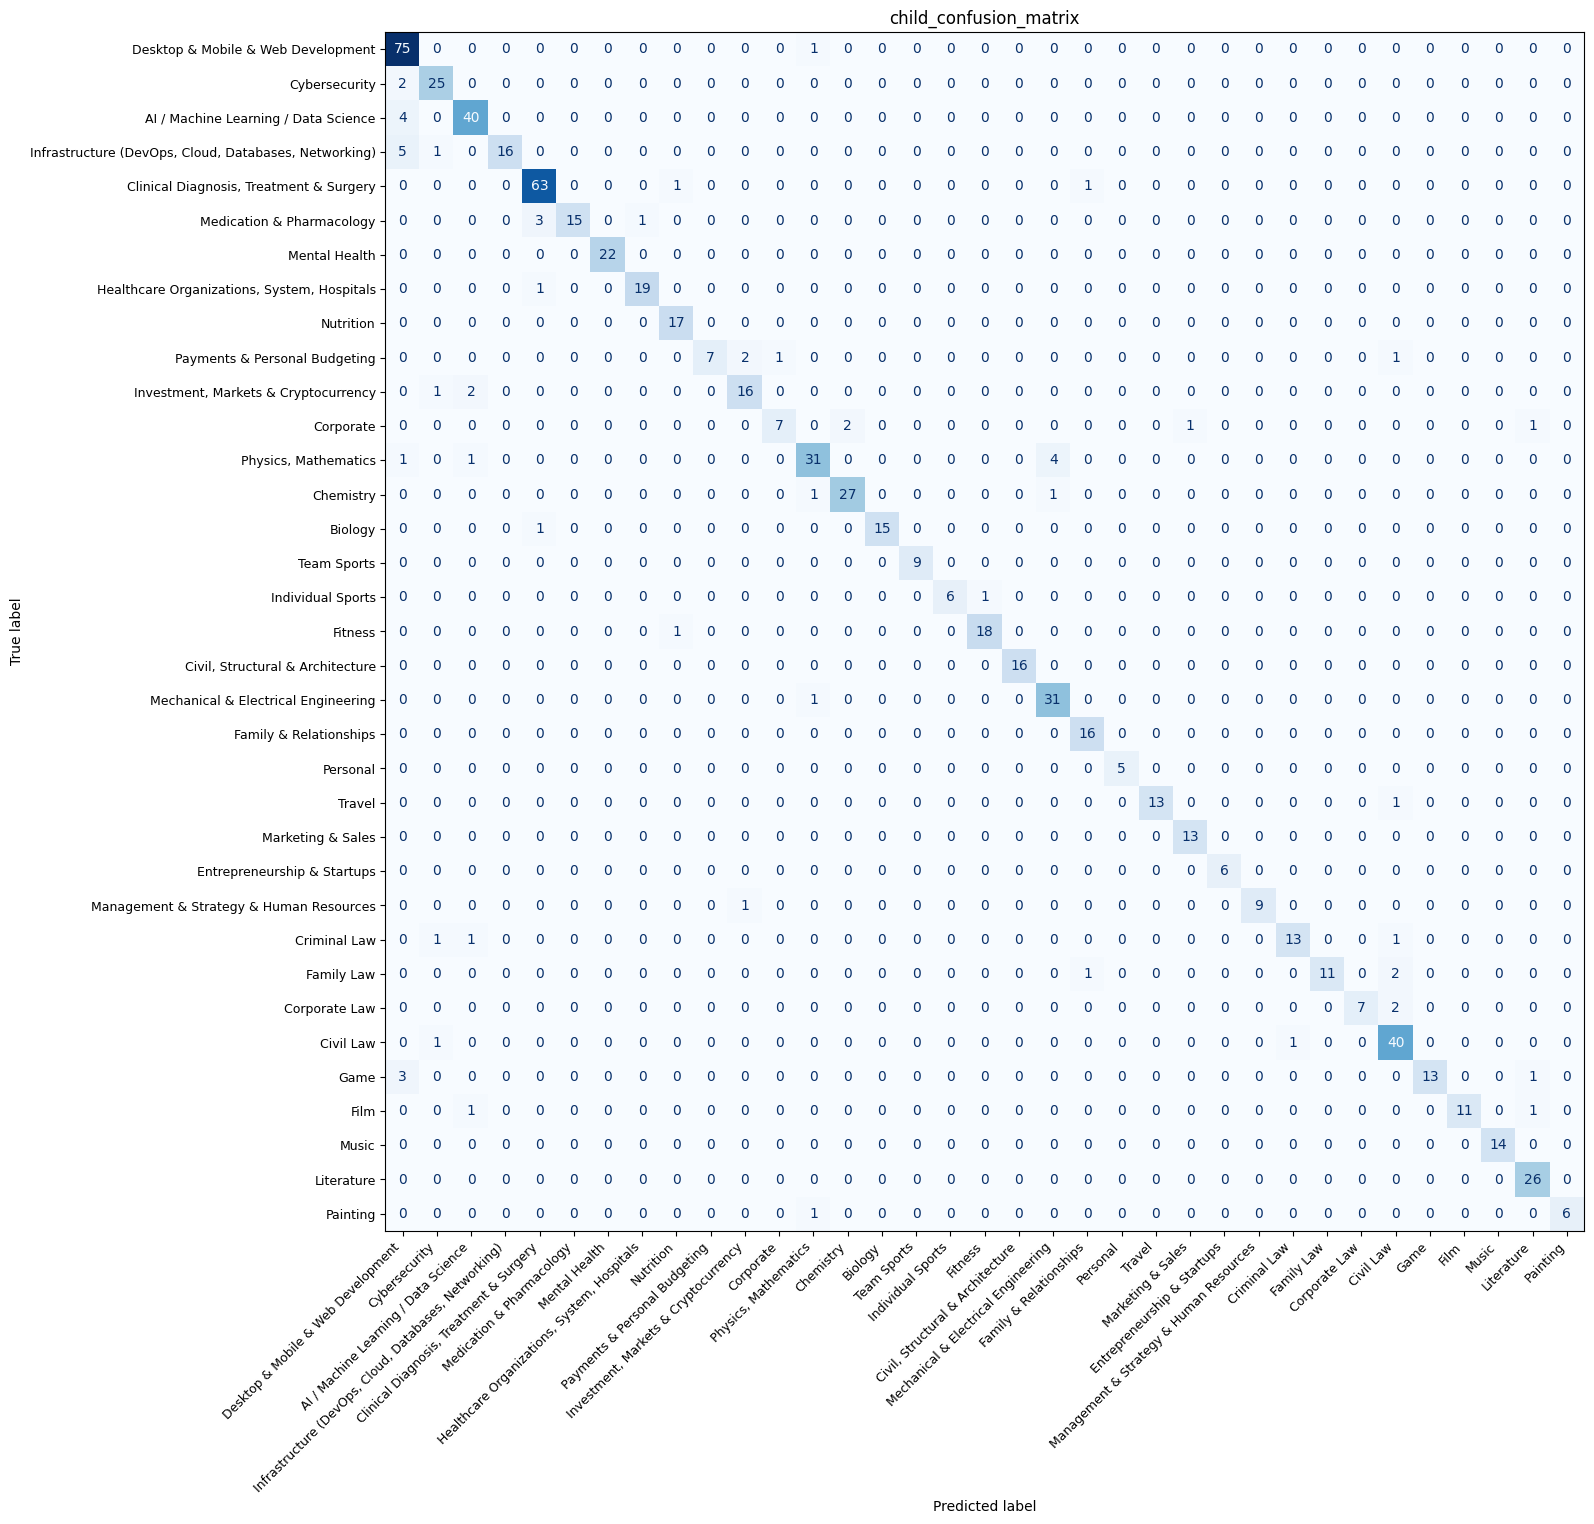

Saved to confusion_matrix.png


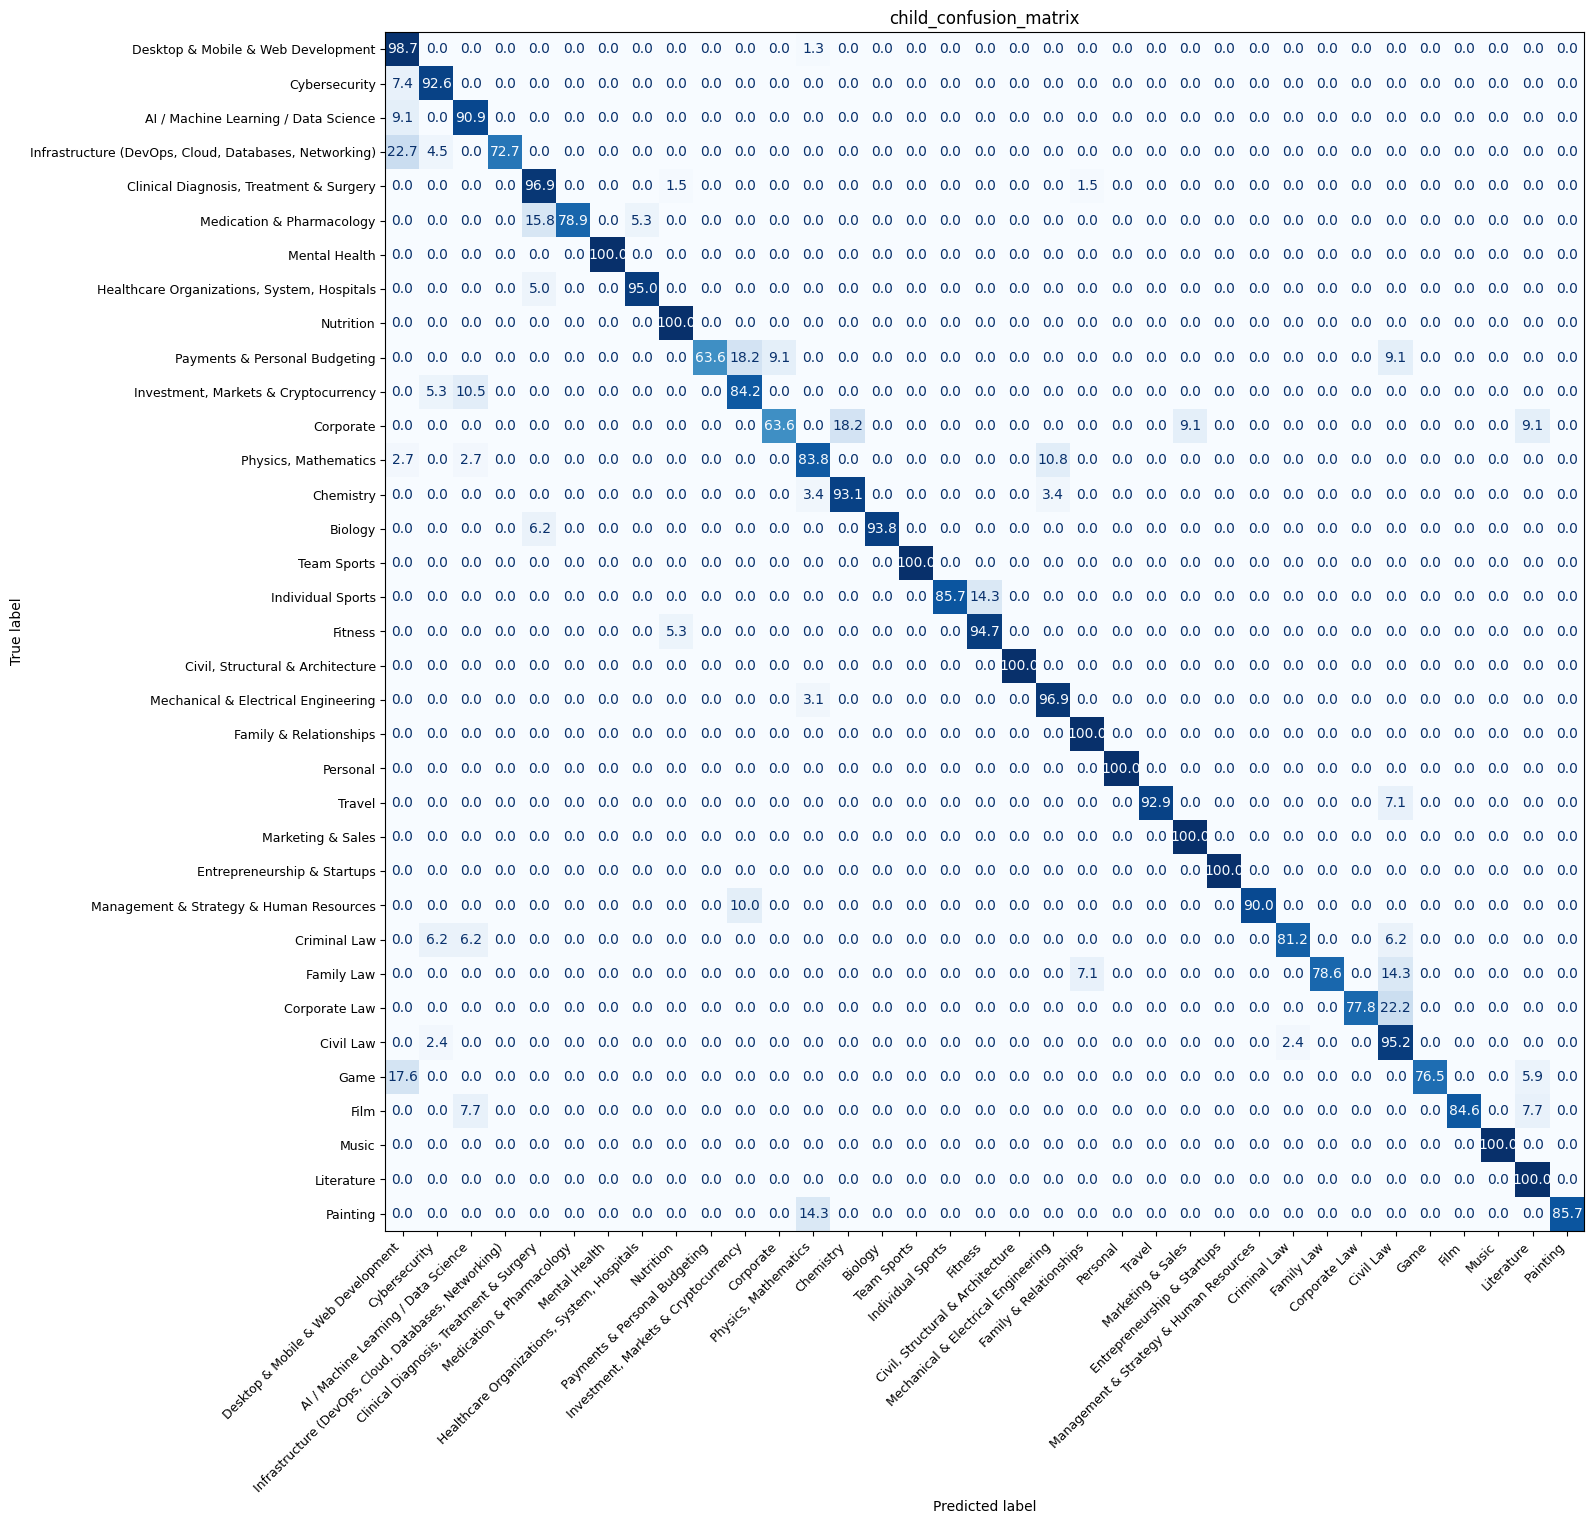

Saved to misclassification_confusion_matrix.png


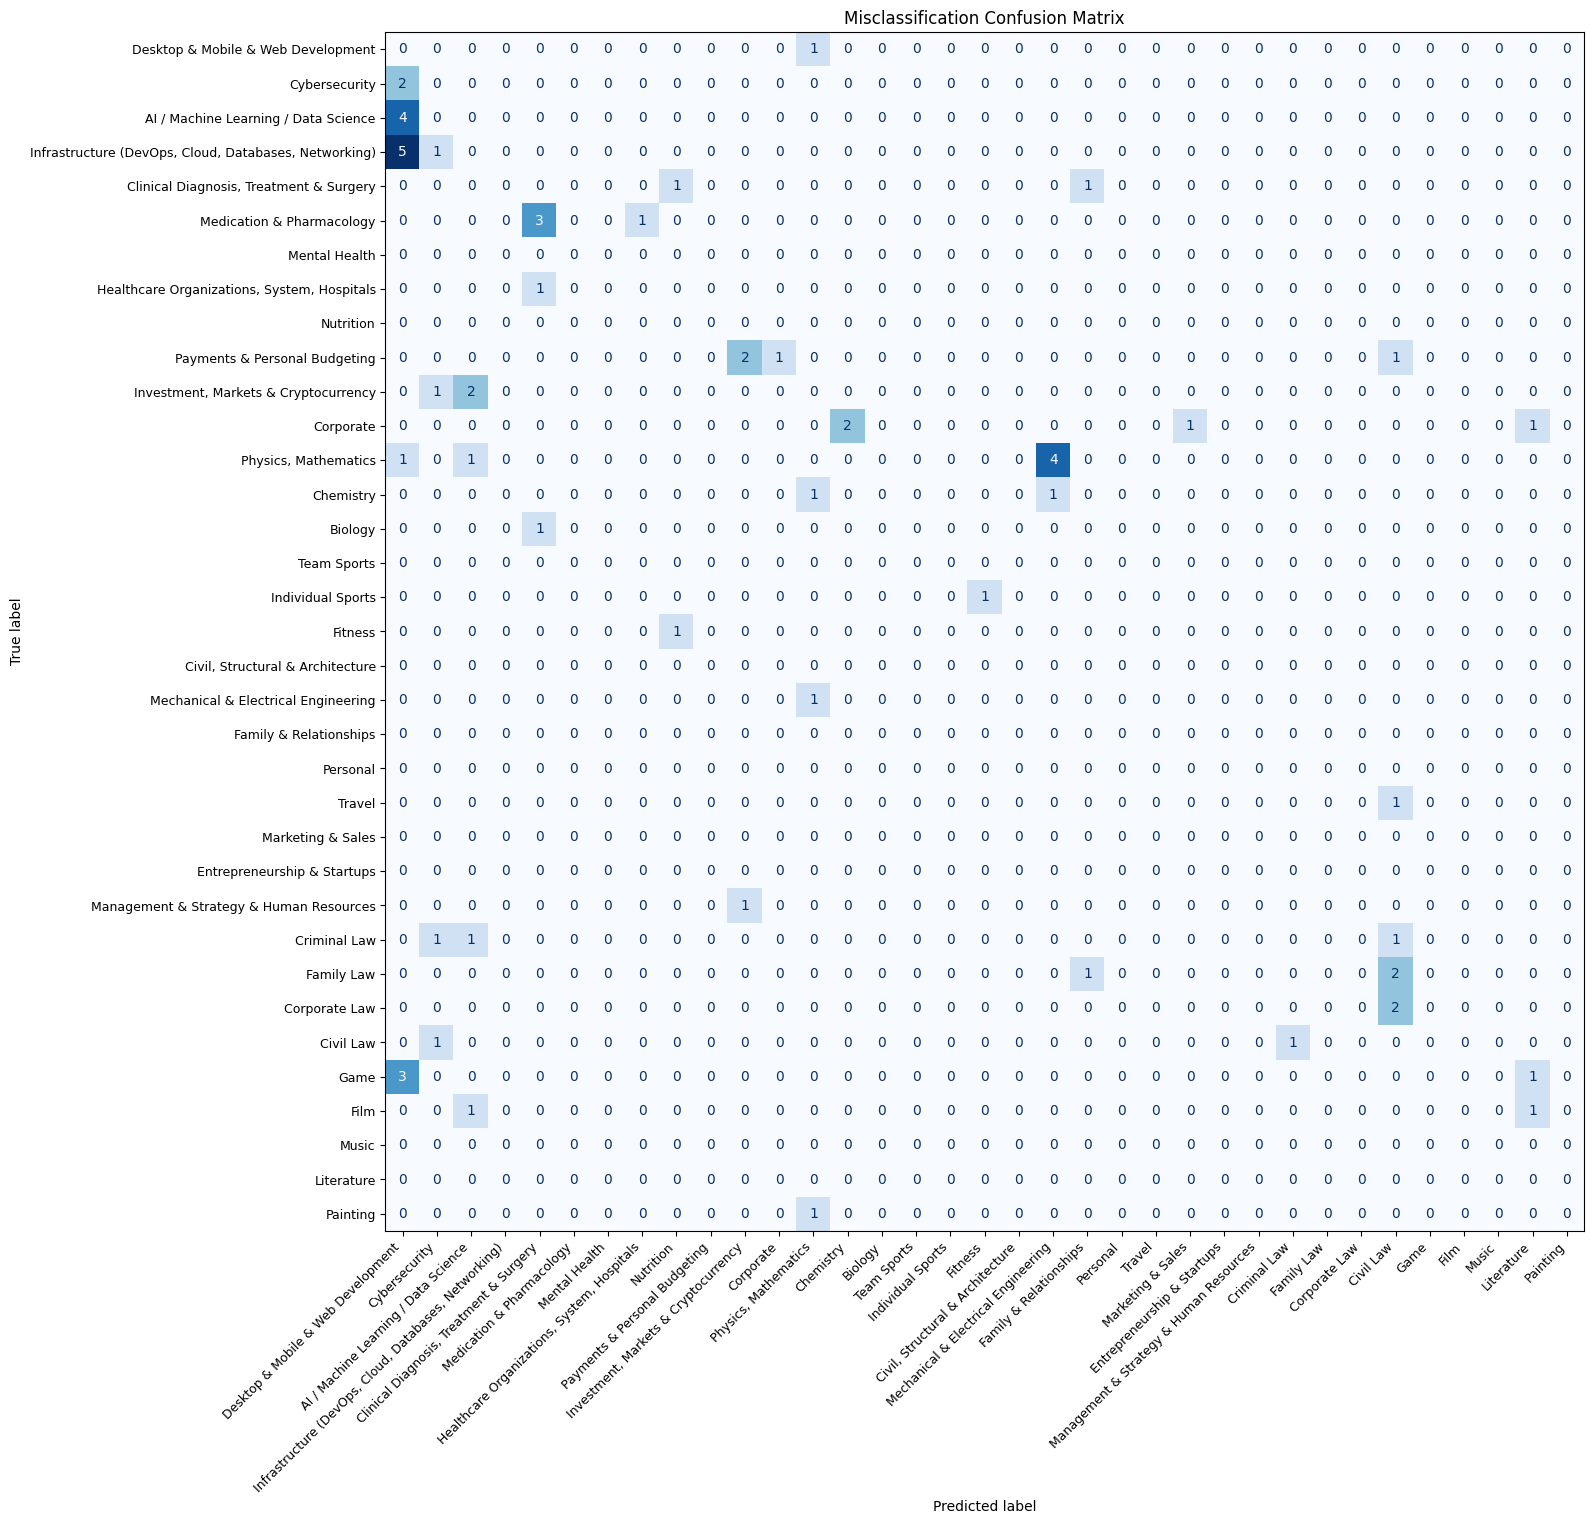

,Parent,Precision Min,Precision Avg,Precision Max,Recall Min,Recall Avg,Recall Max,F1 Min,F1 Avg,F1 Max,Support
0,Programming / Technology,83.33%,89.61%,100.00%,72.73%,88.73%,98.68%,84.21%,88.44%,90.36%,169.0
1,Medical,89.47%,95.42%,100.00%,78.95%,94.17%,100.00%,88.24%,94.48%,100.00%,143.0
2,Finance,84.21%,90.57%,100.00%,63.64%,70.49%,84.21%,73.68%,78.56%,84.21%,41.0
3,Science,88.57%,93.89%,100.00%,83.78%,90.21%,93.75%,86.11%,92.00%,96.77%,82.0
4,Sports,94.74%,98.25%,100.00%,85.71%,93.48%,100.00%,92.31%,95.68%,100.00%,35.0
5,Engineering,86.11%,93.06%,100.00%,96.88%,98.44%,100.00%,91.18%,95.59%,100.00%,48.0
6,Personal,88.89%,96.30%,100.00%,92.86%,97.62%,100.00%,94.12%,96.80%,100.00%,35.0
7,Business,92.86%,97.62%,100.00%,90.00%,96.67%,100.00%,94.74%,97.01%,100.00%,29.0
8,Law,85.11%,94.49%,100.00%,77.78%,83.21%,95.24%,86.67%,88.01%,89.89%,81.0
9,Art,89.66%,97.93%,100.00%,76.47%,89.36%,100.00%,86.67%,93.04%,100.00%,77.0


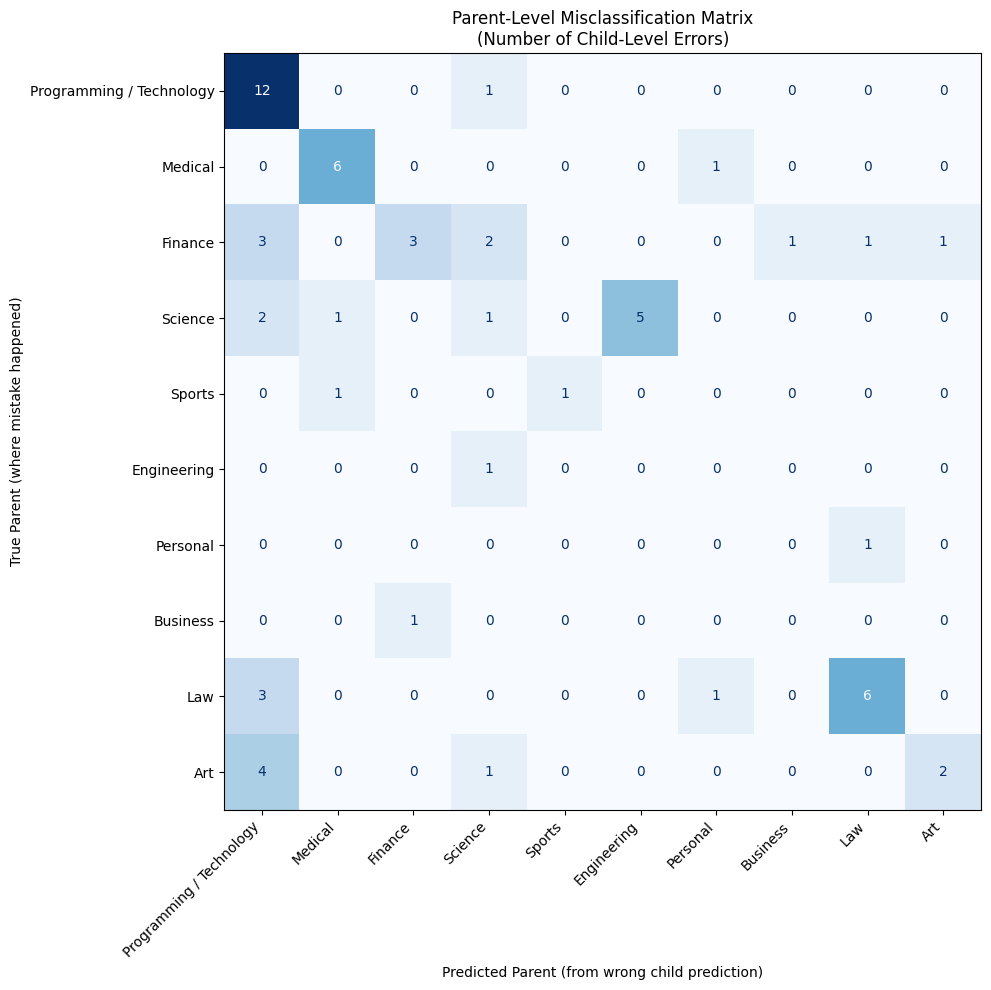

Showing 15 random misclassified samples out of 62

────────────────────────────────────────────────────────────────────────────────────────────────────
Sample 1  |  Test index: 38
────────────────────────────────────────────────────────────────────────────────────────────────────
True label     : Individual Sports
Predicted label: Fitness

Top 10 probabilities:
 1. Fitness                                  0.3990 ( 39.90%) <-- PREDICTED
 2. Individual Sports                        0.1819 ( 18.19%) <-- TRUE
 3. Clinical Diagnosis, Treatment & Surgery  0.0993 (  9.93%)
 4. Team Sports                              0.0414 (  4.14%)
 5. Mechanical & Electrical Engineering      0.0204 (  2.04%)
 6. Nutrition                                0.0179 (  1.79%)
 7. Physics, Mathematics                     0.0166 (  1.66%)
 8. Personal                                 0.0150 (  1.50%)
 9. Game                                     0.0147 (  1.47%)
10. Biology                                  0.0138 (  

In [ ]:
(
    df_test_filtered,
    y_test_filtered,
    y_pred_filtered,
    probabilities_filtered,
    original_indices,
    filter_info,
) = evaluate_filtered_model(
    df_test=df_test,
    label_order=label_order,
    id_to_label=id_to_label,
    hierarchy=HIERARCHY,
    filter_function=filter_by_probability_gap,
    filter_kwargs={
        "min_gap": 0.1,
    },
    predictions_path="test_predictions.npz",
)

### cm

Saved to confusion_matrix.png


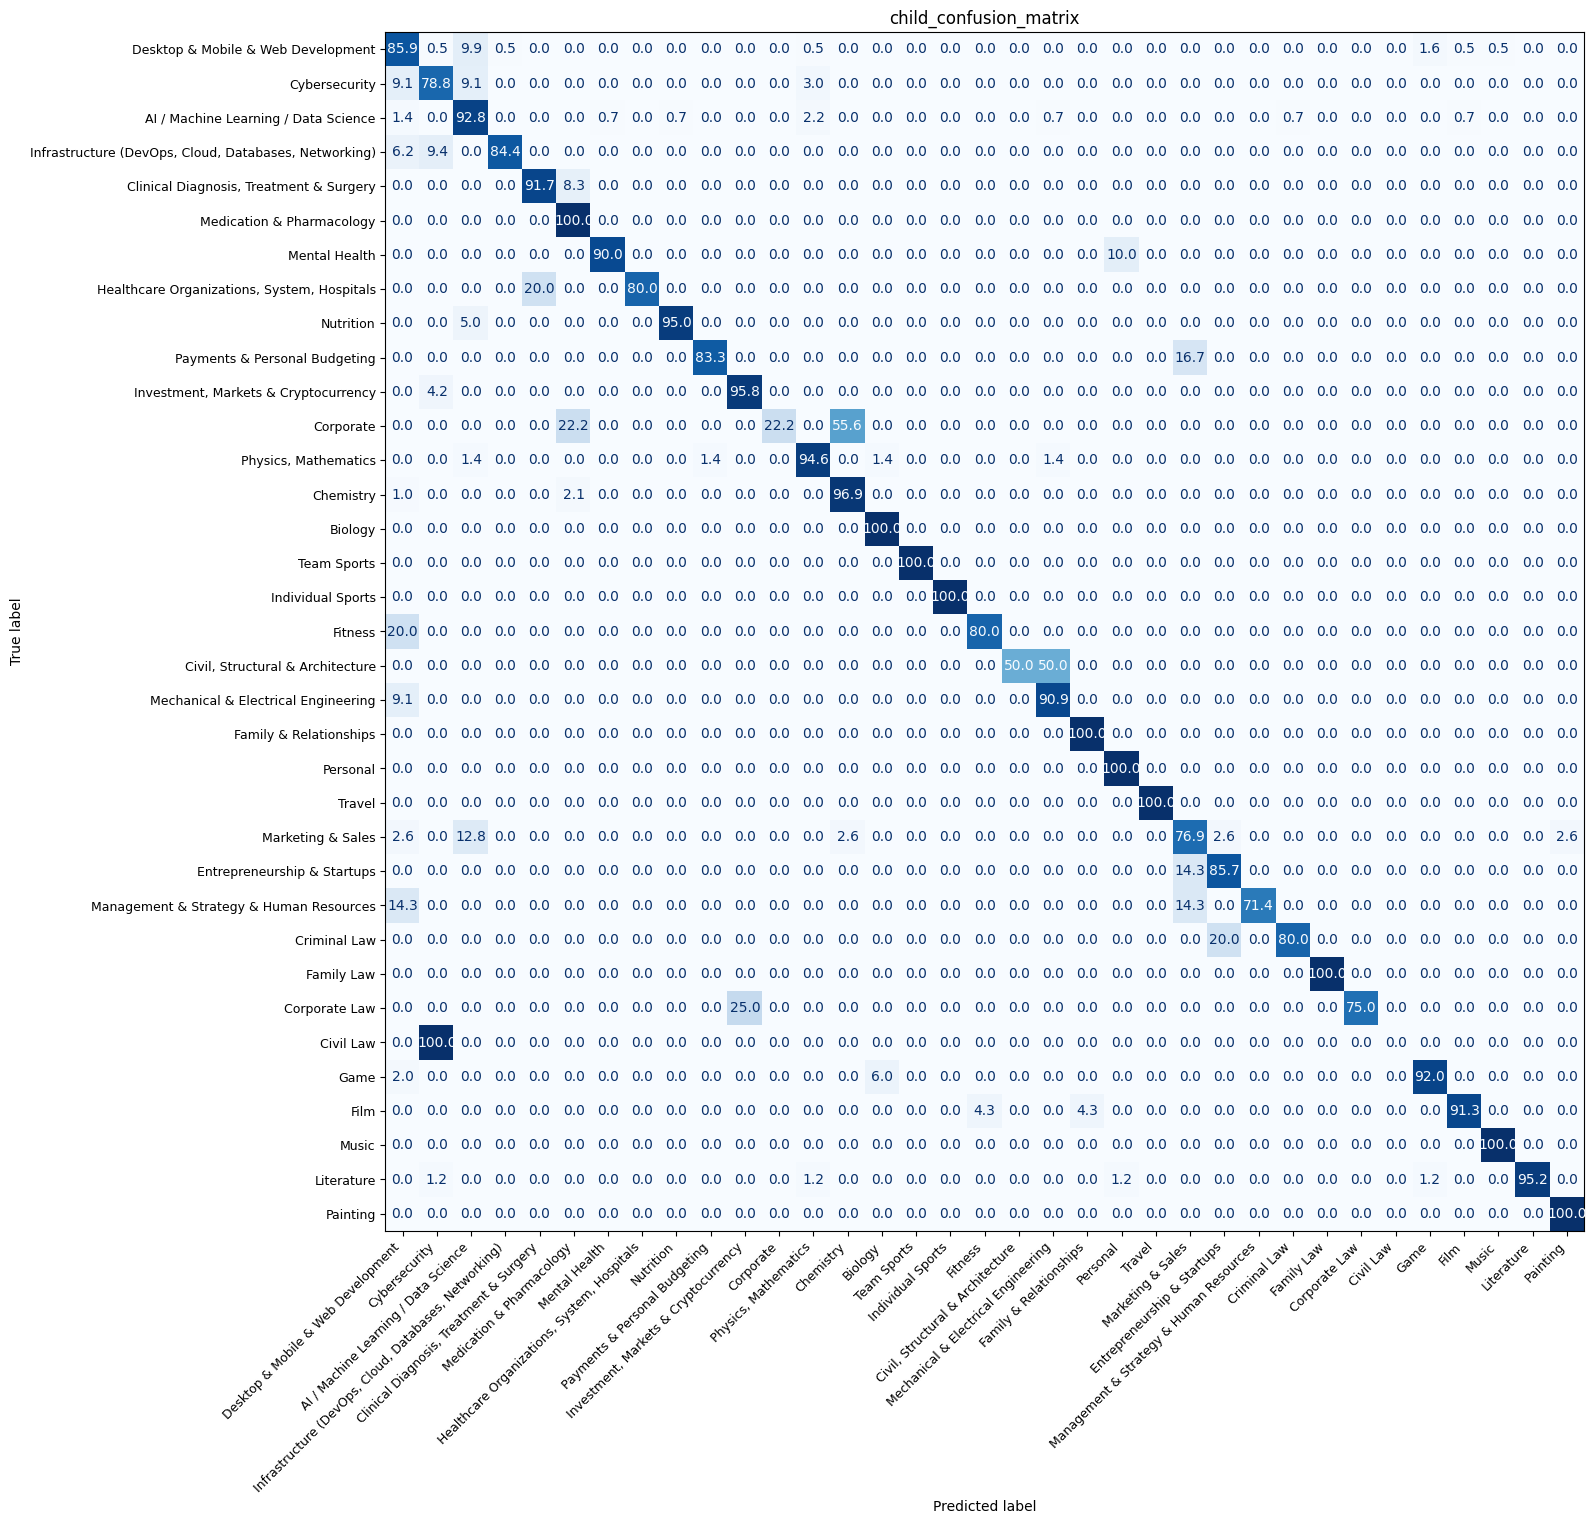

In [ ]:
plot_child_confusion_matrix(
    y_test_filtered,
    y_pred_filtered,
    label_order,
)

Saved to confusion_matrix.png


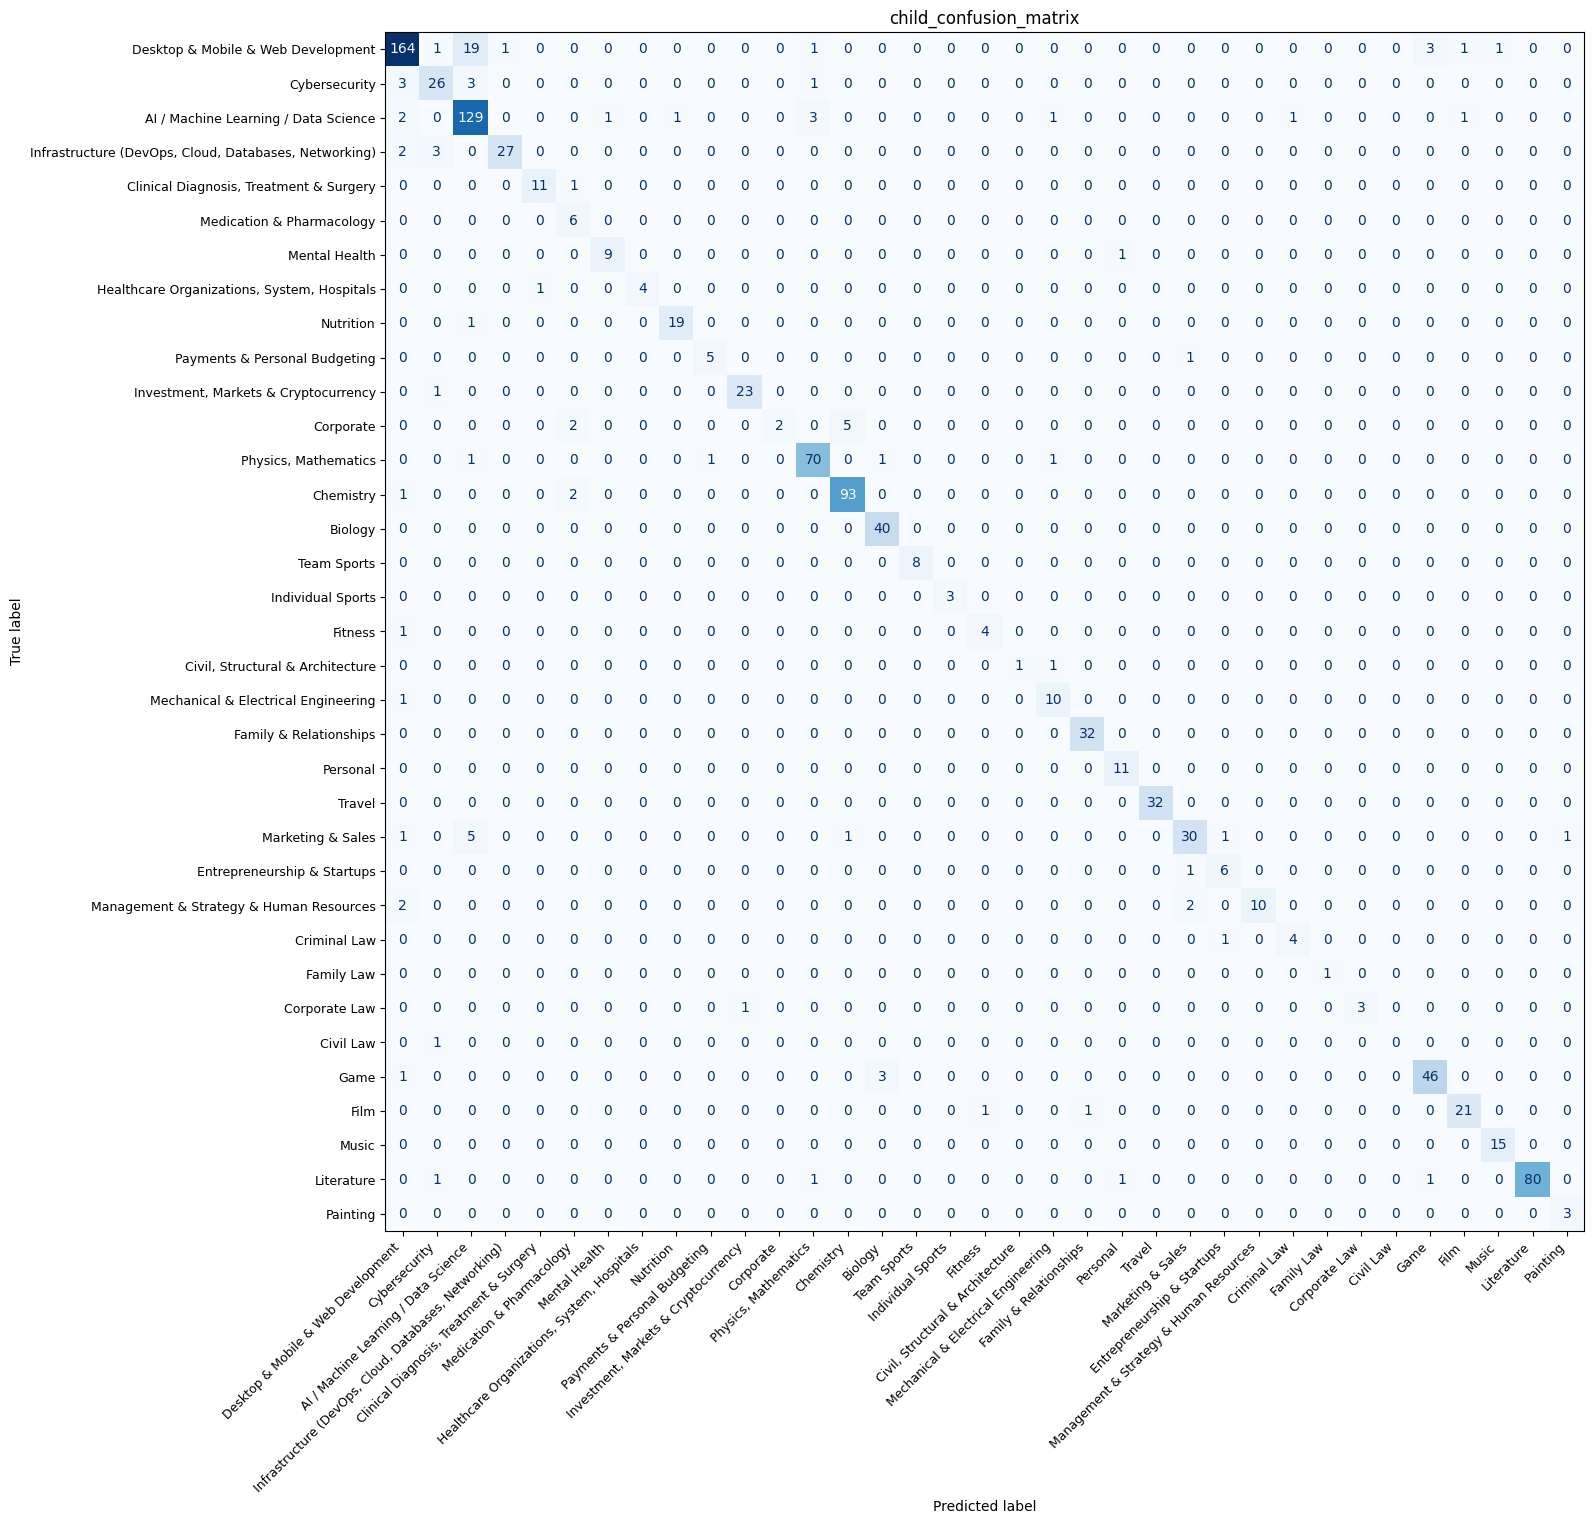

In [ ]:
plot_child_confusion_matrix_old(
    y_test_filtered,
    y_pred_filtered,
    label_order,
)

In [ ]:
import json
import pandas as pd

# Copy only confident test samples
df_filtered = df_test.iloc[np.where(confident_mask)[0]].copy()

# Add prediction
df_filtered["predicted_label"] = y_pred_filtered

# Add confidence
df_filtered["confidence"] = confidence[confident_mask]

# Save
df_filtered.to_json(
    "filtered_test_results.json",
    orient="records",
    force_ascii=False,
    indent=2,
)

print(f"Saved {len(df_filtered)} samples")
print("Saved to: filtered_test_results.json")

NameError: name 'confident_mask' is not defined

In [ ]:
import json

# --------------------------------------------------
# Paths
# --------------------------------------------------

INPUT_PATH = "/content/filtered_test_results.json"
OUTPUT_PATH = "classifier_results_real_test.json"


# --------------------------------------------------
# Load input JSON
# --------------------------------------------------

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    data = json.load(f)


# --------------------------------------------------
# Convert
# --------------------------------------------------

output = []

for shuffled_index, sample in enumerate(data):

    predicted_id = sample["predicted_label"]

    converted_sample = {
        "shuffled_index": shuffled_index,
        "text": sample["text"],
        "label": sample["label"],
        "generation_group": "Null",
        "llm_prediction": label_order[predicted_id],
    }

    output.append(converted_sample)


# --------------------------------------------------
# Save
# --------------------------------------------------

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(output, f, ensure_ascii=False, indent=2)

print(f"Saved {len(output)} samples to {OUTPUT_PATH}")